In [1]:
import ray_tracing_cuda_float_torch as rt
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.optimize as so
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from algorithms import Algorithms
import time
import pywt
from skimage.metrics import peak_signal_noise_ratio as psnr
import imageio.v3 as iio
import sigpy


In [2]:
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu' )
n = 512

img = torch.tensor( sigpy.shepp_logan( shape = ( n, n ), dtype = np.float32 ), device = 'cuda' )

( radon, radon_transpose ) = rt.make_radon_transp(
    ( n, n ),
    sino_top_left = ( 0.0, 1.0 ),
    sino_bottom_right = ( torch.pi, -1.0 ),
    img_shape = ( n, n )    
)

In [3]:
b = radon( img )

torch.manual_seed( 42 )
nivel_ruido = 0.05
ruido = torch.randn_like( b ) * nivel_ruido * torch.max( b )
b = b + ruido


In [4]:
def A( x ):
    return radon( x )

def A_transpose( x ):
    return radon_transpose( x )

def ATA( x ):
    return radon_transpose( radon( x ) )


In [5]:
#são adjuntas??

x = torch.randn( *img.shape, device = img.device )
y = torch.randn( *img.shape, device = img.device )

print( ( y * radon( x ) ).sum() )
print( ( x * radon_transpose( y ) ).sum() )

#okay

tensor(-30.8652, device='cuda:0')
tensor(-30.8652, device='cuda:0')


In [6]:
#vendo se L é adjunta de LT (y'Lx = x'LTy)

def L( p, q ):

        P = torch.nn.functional.pad(p, ( 0, 0, 1, 1 ), mode = 'constant', value = 0 )
        Q = torch.nn.functional.pad(q, ( 1, 1, 0, 0 ), mode = 'constant', value = 0 )
        
        return ( P[ 1:, : ] + Q[ :, 1:  ] - P[ :-1, : ] - Q[ :, :-1 ] )

def LT( b ):
    p = b[ :-1, : ] - b[ 1:, : ]
    q = b[ :, :-1 ] - b[ :, 1: ]

    return p, q

N, M = 10, 10

p = torch.randn( N - 1, M )
q = torch.randn( N, M - 1 )
y = torch.randn( N, M )

L_pq = L( p, q )
p_adj, q_adj = LT( y )

print( torch.sum( L_pq * y ) )

print( torch.sum( p * p_adj ) + torch.sum( q * q_adj ) )

tensor(-3.5606)
tensor(-3.5606)


In [7]:
def spectral_norm( Q, shape, device = 'cuda', n_iter = 50, tol = 1e-6 ):#método das potências
    v = torch.randn( shape, device = device )
    v = v / torch.norm( v )
    
    lambda_old = 0.0
    
    for i in range( n_iter ):
        # 2. Aplica o operador Q(x) = A'A x
        w = Q( v )
        
        lambda_max = torch.sum( v * w ).item()
        
        v = w / torch.norm(w)
        
        if abs( lambda_max - lambda_old ) < tol:
            break
        lambda_old = lambda_max
            
    return lambda_max

L_constant = spectral_norm( ATA, ( n, n ) )
print( f"Norma Espectral (L): {L_constant}" )
print( f"Passo máximo (1/L): {1/L_constant}" )

Norma Espectral (L): 3.8202481269836426
Passo máximo (1/L): 0.26176310196625135


In [8]:
def f( x ):
    return 1/2 * ( ( A( x ) - b ) ** 2 ).sum()

def grad_f( x ):
    return A_transpose( A( x ) - b )

def g( x, **kwargs ):
    diff_i = x[ :-1, :-1 ] - x[ 1:, :-1 ]
    diff_j = x[ :-1, :-1 ] - x[ :-1, 1: ]

    res_i = x[ :-1, -1 ] - x[ 1:, -1 ]
    res_j = x[ -1, :-1 ] - x[ -1, 1: ]

    return torch.sum( ( diff_i ** 2 + diff_j ** 2 ) ** 0.5 ) + torch.sum( torch.abs( res_i ) ) + torch.sum( torch.abs( res_j ) )


# Encontrando o melhor parâmetro de regularização

[tensor(31.8842, device='cuda:0'), tensor(25.2901, device='cuda:0'), tensor(18.0459, device='cuda:0'), tensor(15.2576, device='cuda:0'), tensor(16.5457, device='cuda:0'), tensor(21.7283, device='cuda:0'), tensor(36.4556, device='cuda:0'), tensor(51.3163, device='cuda:0'), tensor(79.0923, device='cuda:0')]
Gamma ótimo: 0.005
Menor erro absoluto atingido: 15.257645606994629


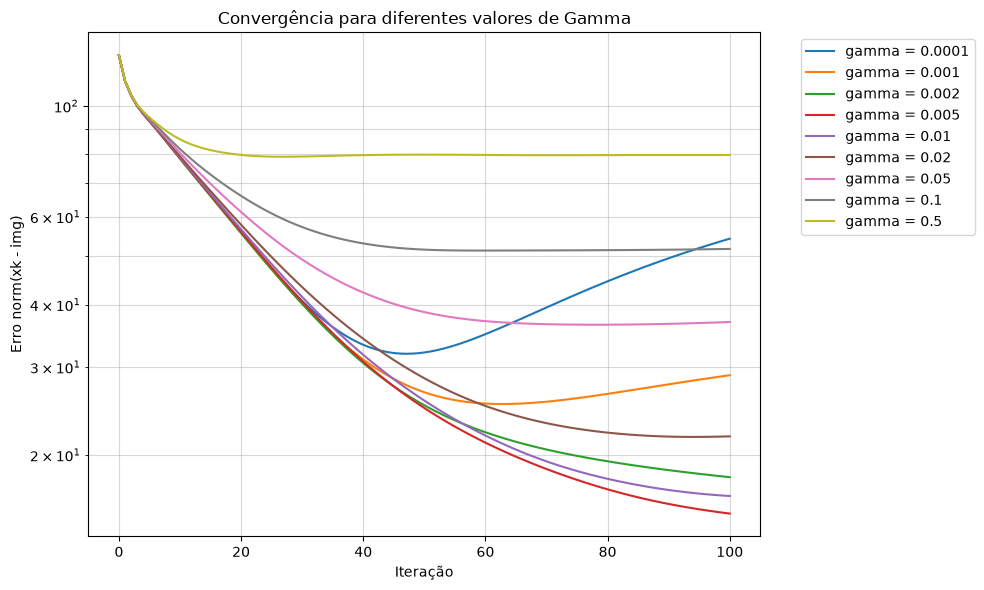

In [9]:
gammas = [ 0.0001, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.5 ]
step = 0.1
x0 = torch.zeros_like( b )
prox = Algorithms.prox_tv
tol = 1.0e-10
max_iter = 100 
kwargs = {'max_iter_tv' : 15, 'L' : L, 'LT' : LT, 'proj_P' : Algorithms.proj_P}

min_errors = []
error_histories = {} 

for gamma in gammas:
    iters = Algorithms.fista_fixo( f = f, grad_f = grad_f, prox = prox, x0 = x0, step = step, 
                                   gamma = gamma, max_iter = max_iter, tol = tol, **kwargs )
    
    errors_k = [ torch.linalg.norm( xk - img ) for xk in iters ]
    
    error_histories[ gamma ] = errors_k 
    min_errors.append( min( errors_k ) )

print( min_errors )
idx_best = torch.argmin( torch.tensor( min_errors ) ).item()
gamma_star = gammas[ idx_best ]

print( f"Gamma ótimo: {gamma_star}" )
print( f"Menor erro absoluto atingido: {min_errors[ idx_best ]}" )

plt.figure( figsize = ( 10, 6 ) )

for gamma in gammas:
    plt.plot( torch.tensor( error_histories[ gamma ] ).to( 'cpu' ), label = f"gamma = {gamma}" )

plt.yscale( 'log' )
plt.xlabel( 'Iteração' )
plt.ylabel( 'Erro norm(xk - img)' )
plt.title( 'Convergência para diferentes valores de Gamma' )
plt.legend( bbox_to_anchor = ( 1.05, 1 ), loc = 'upper left' )
plt.grid( True, which = "both", ls = "-", alpha = 0.5 )
plt.tight_layout()

plt.show()

# Primeiros testes entre todos os algoritmos

In [9]:
def compare_methods( methods, f, F_obj, grad_f, prox, x0, gamma, tol = 1e-4, max_iter = 1000, runs = 5, **kwargs ):
    results = {}
    device = x0.device
    is_cuda = device.type == 'cuda'

    for name, method in methods.items():
        print( f"Testando {name} ({runs} execuções)..." )
        
        _ = method( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, tol = tol, max_iter = max_iter, **kwargs )
        
        times = []
        last_iters = None
        
        for _ in range( runs ):
            if is_cuda:
                torch.cuda.synchronize()
            
            start = time.perf_counter()
            iters = method( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, tol = tol, max_iter = max_iter, **kwargs )
            if is_cuda:
                torch.cuda.synchronize()
            
            end = time.perf_counter()
            times.append( end - start )
            last_iters = iters

        times_tensor = torch.tensor( times )
        avg_time = torch.mean( times_tensor ).item()
        std_dev = torch.std( times_tensor ).item()
        
        values = [ F_obj( x ).item() for x in last_iters ]
        
        results[ name ] = {
            "iterations": len( last_iters ),
            "avg_time": avg_time,
            "std_dev": std_dev,
            "function_values": values,
            "iters": last_iters
        }
        
        print( f"{name}: {avg_time:.4f}s ± {std_dev:.4f}s ( {len( last_iters )} iterações )" )
    
    return results

def get_metrics( img_true, img_test ):
    p = psnr( img_true, img_test, data_range = img_true.max() - img_true.min() )
    return p


## Testando com o $\gamma = 0.005$ ótimo

In [9]:
step = 0.2
gamma = 0.005
x0 = torch.zeros_like( b )
prox = Algorithms.prox_tv
tol = 1.0e-3
max_iter = 999
kwargs = {'max_iter_tv' : 15, 
          'L' : L, 
          'LT' : LT, 
          'proj_P' : Algorithms.proj_P,
          'A' : radon}


In [11]:
methods = {
    "FISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_fixo(f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "ISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.ista_exato( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "FISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_exato( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "FISTA Backtracking": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_backtracking(f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, beta = 0.95, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs )
}

F_obj = lambda x: f( x ) + gamma * g( x )

results = compare_methods( 
    methods = methods, 
    f = f, 
    F_obj = F_obj,
    grad_f = grad_f, 
    prox = prox, 
    x0 = x0, 
    gamma = gamma, 
    max_iter = max_iter, 
    tol = tol, 
    **kwargs 
)

F_star = min( [ min( res['function_values'] ) for res in results.values() ] )
print( f"Menor valor F_star global: {F_star}" )

Testando FISTA Fixo (5 execuções)...
FISTA Fixo: 14.7079s ± 0.0196s ( 848 iterações )
Testando ISTA Exato (5 execuções)...
ISTA Exato: 20.7099s ± 0.0312s ( 1000 iterações )
Testando FISTA Exato (5 execuções)...
FISTA Exato: 20.7782s ± 0.0437s ( 1000 iterações )
Testando FISTA Backtracking (5 execuções)...
FISTA Backtracking: 17.6099s ± 1.0391s ( 668 iterações )
Menor valor F_star global: 109.53617095947266


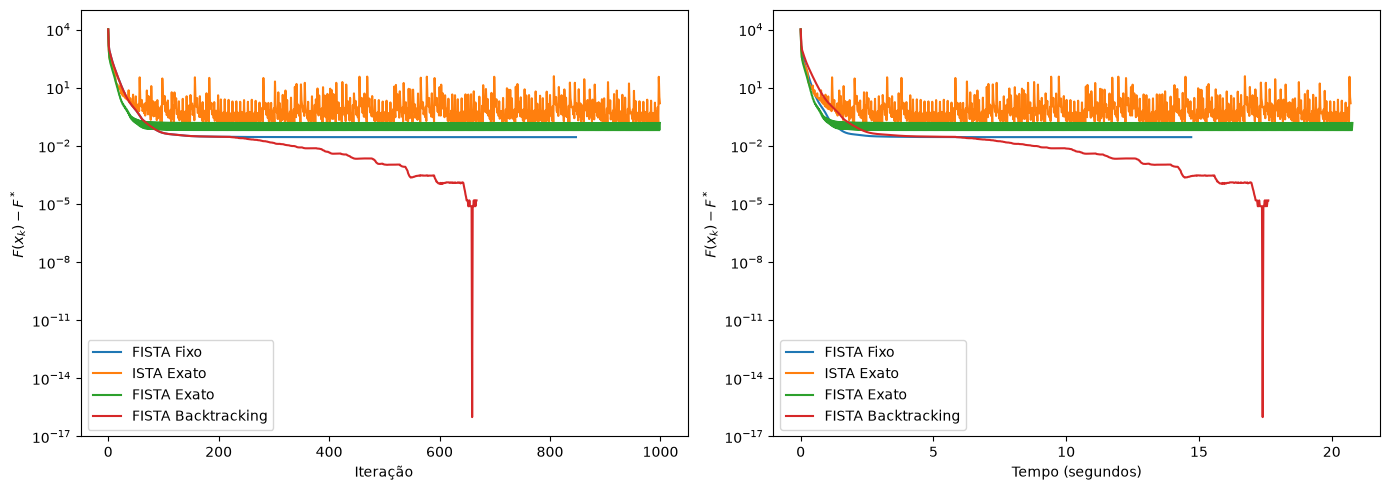

In [12]:
epsilon = 1e-16

names = list( results.keys() )

plt.figure( figsize = ( 14, 5 ) )

plt.subplot( 1, 2, 1 )
for name in names:
    vals = results[ name ][ "function_values" ]
    diff_vals = [ F - F_star + epsilon for F in vals ]
    plt.semilogy( diff_vals, label = name )

plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()

plt.subplot( 1, 2, 2 )
for name in names:
    vals = np.array( results[ name ][ "function_values" ] )
    diff_vals = vals - F_star + epsilon
    
    total_time = results[ name ][ "avg_time" ]
    times = np.linspace( 0, total_time, len( vals ) )
    
    plt.semilogy( times, diff_vals, label = name )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()

plt.tight_layout()
plt.show()

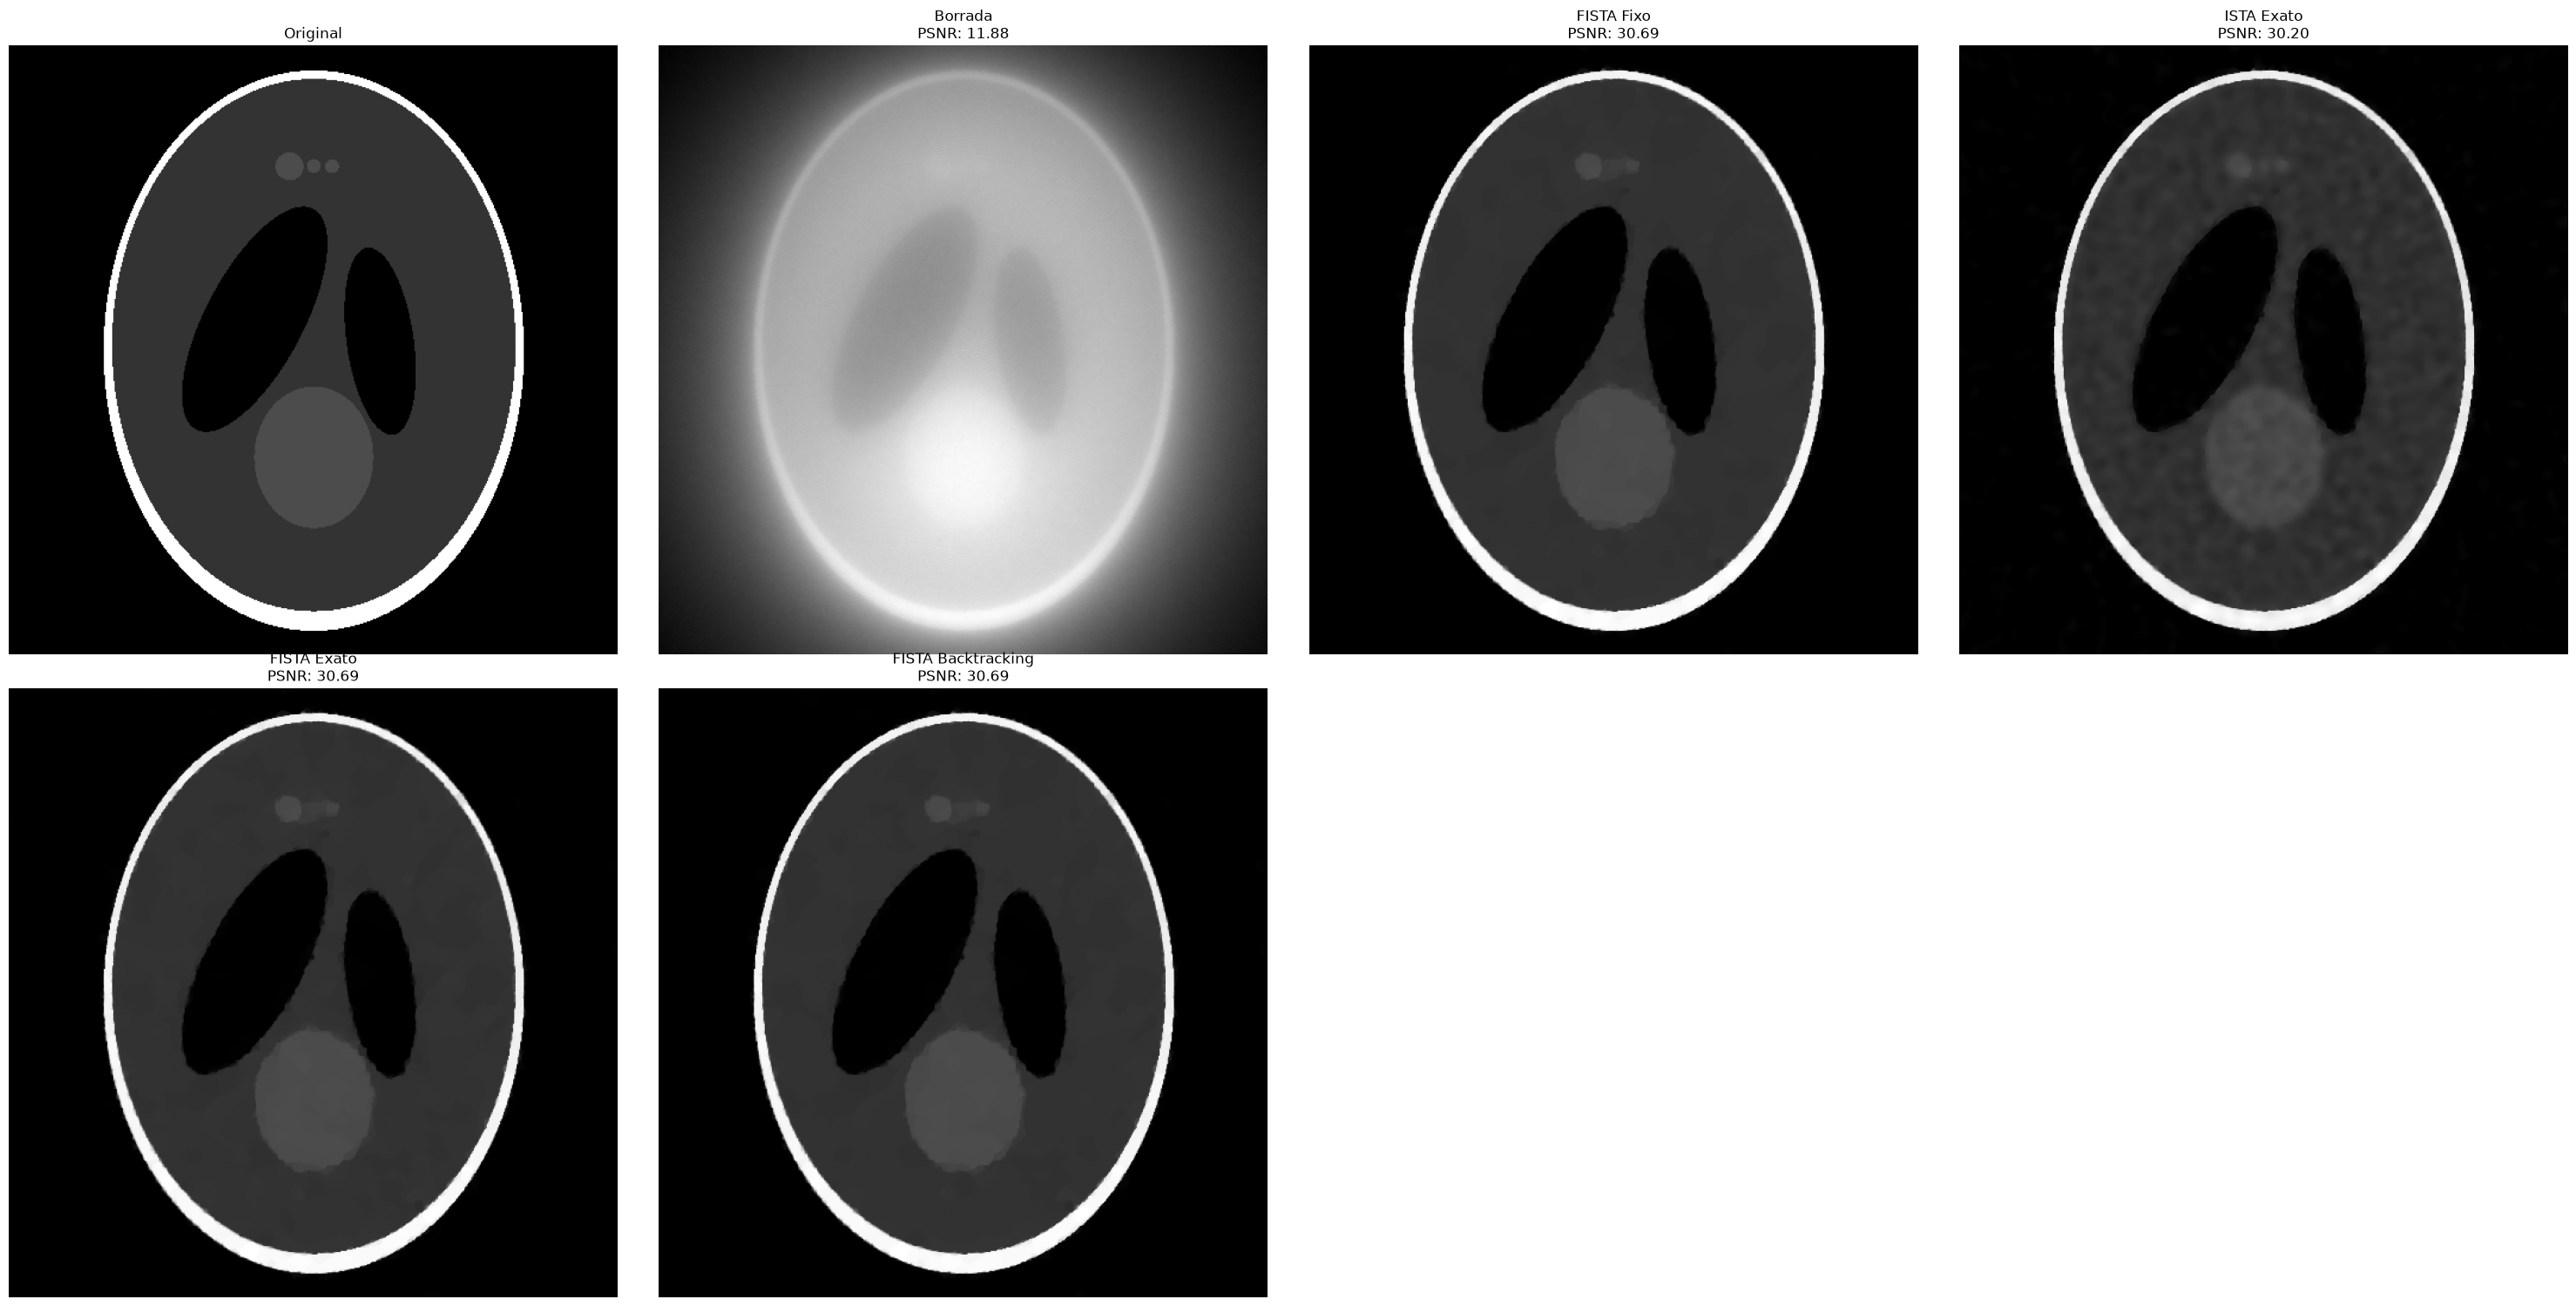

In [14]:
plt.figure( figsize = ( 30, 15 ) )

names = [ "FISTA Fixo", "ISTA Exato", "FISTA Exato", "FISTA Backtracking" ]

plt.subplot( 2, 4, 1 )
plt.imshow( img.to( 'cpu' ).numpy(), cmap = 'gray' )
plt.title( "Original" )
plt.axis( "off" )

p_b = get_metrics( img.to( 'cpu' ).numpy(), b.to( 'cpu' ).numpy() )
plt.subplot( 2, 4, 2 )
plt.imshow( radon_transpose( b ).to( 'cpu' ).numpy(), cmap = 'gray' )
plt.title( f"Borrada\nPSNR: {p_b:.2f}" )
plt.axis( "off" )

for i, name in enumerate( names, start = 3 ):
    res_img = results[ name ][ "iters" ][ -1 ].to( 'cpu' )
    p = get_metrics( img.to( 'cpu' ).numpy(), res_img.to( 'cpu' ).numpy() )
    
    plt.subplot( 2, 4, i )
    plt.imshow( res_img, cmap = 'gray' )
    plt.title( f"{name}\nPSNR: {p:.2f}" )
    plt.axis( "off" )

plt.tight_layout()
plt.show()

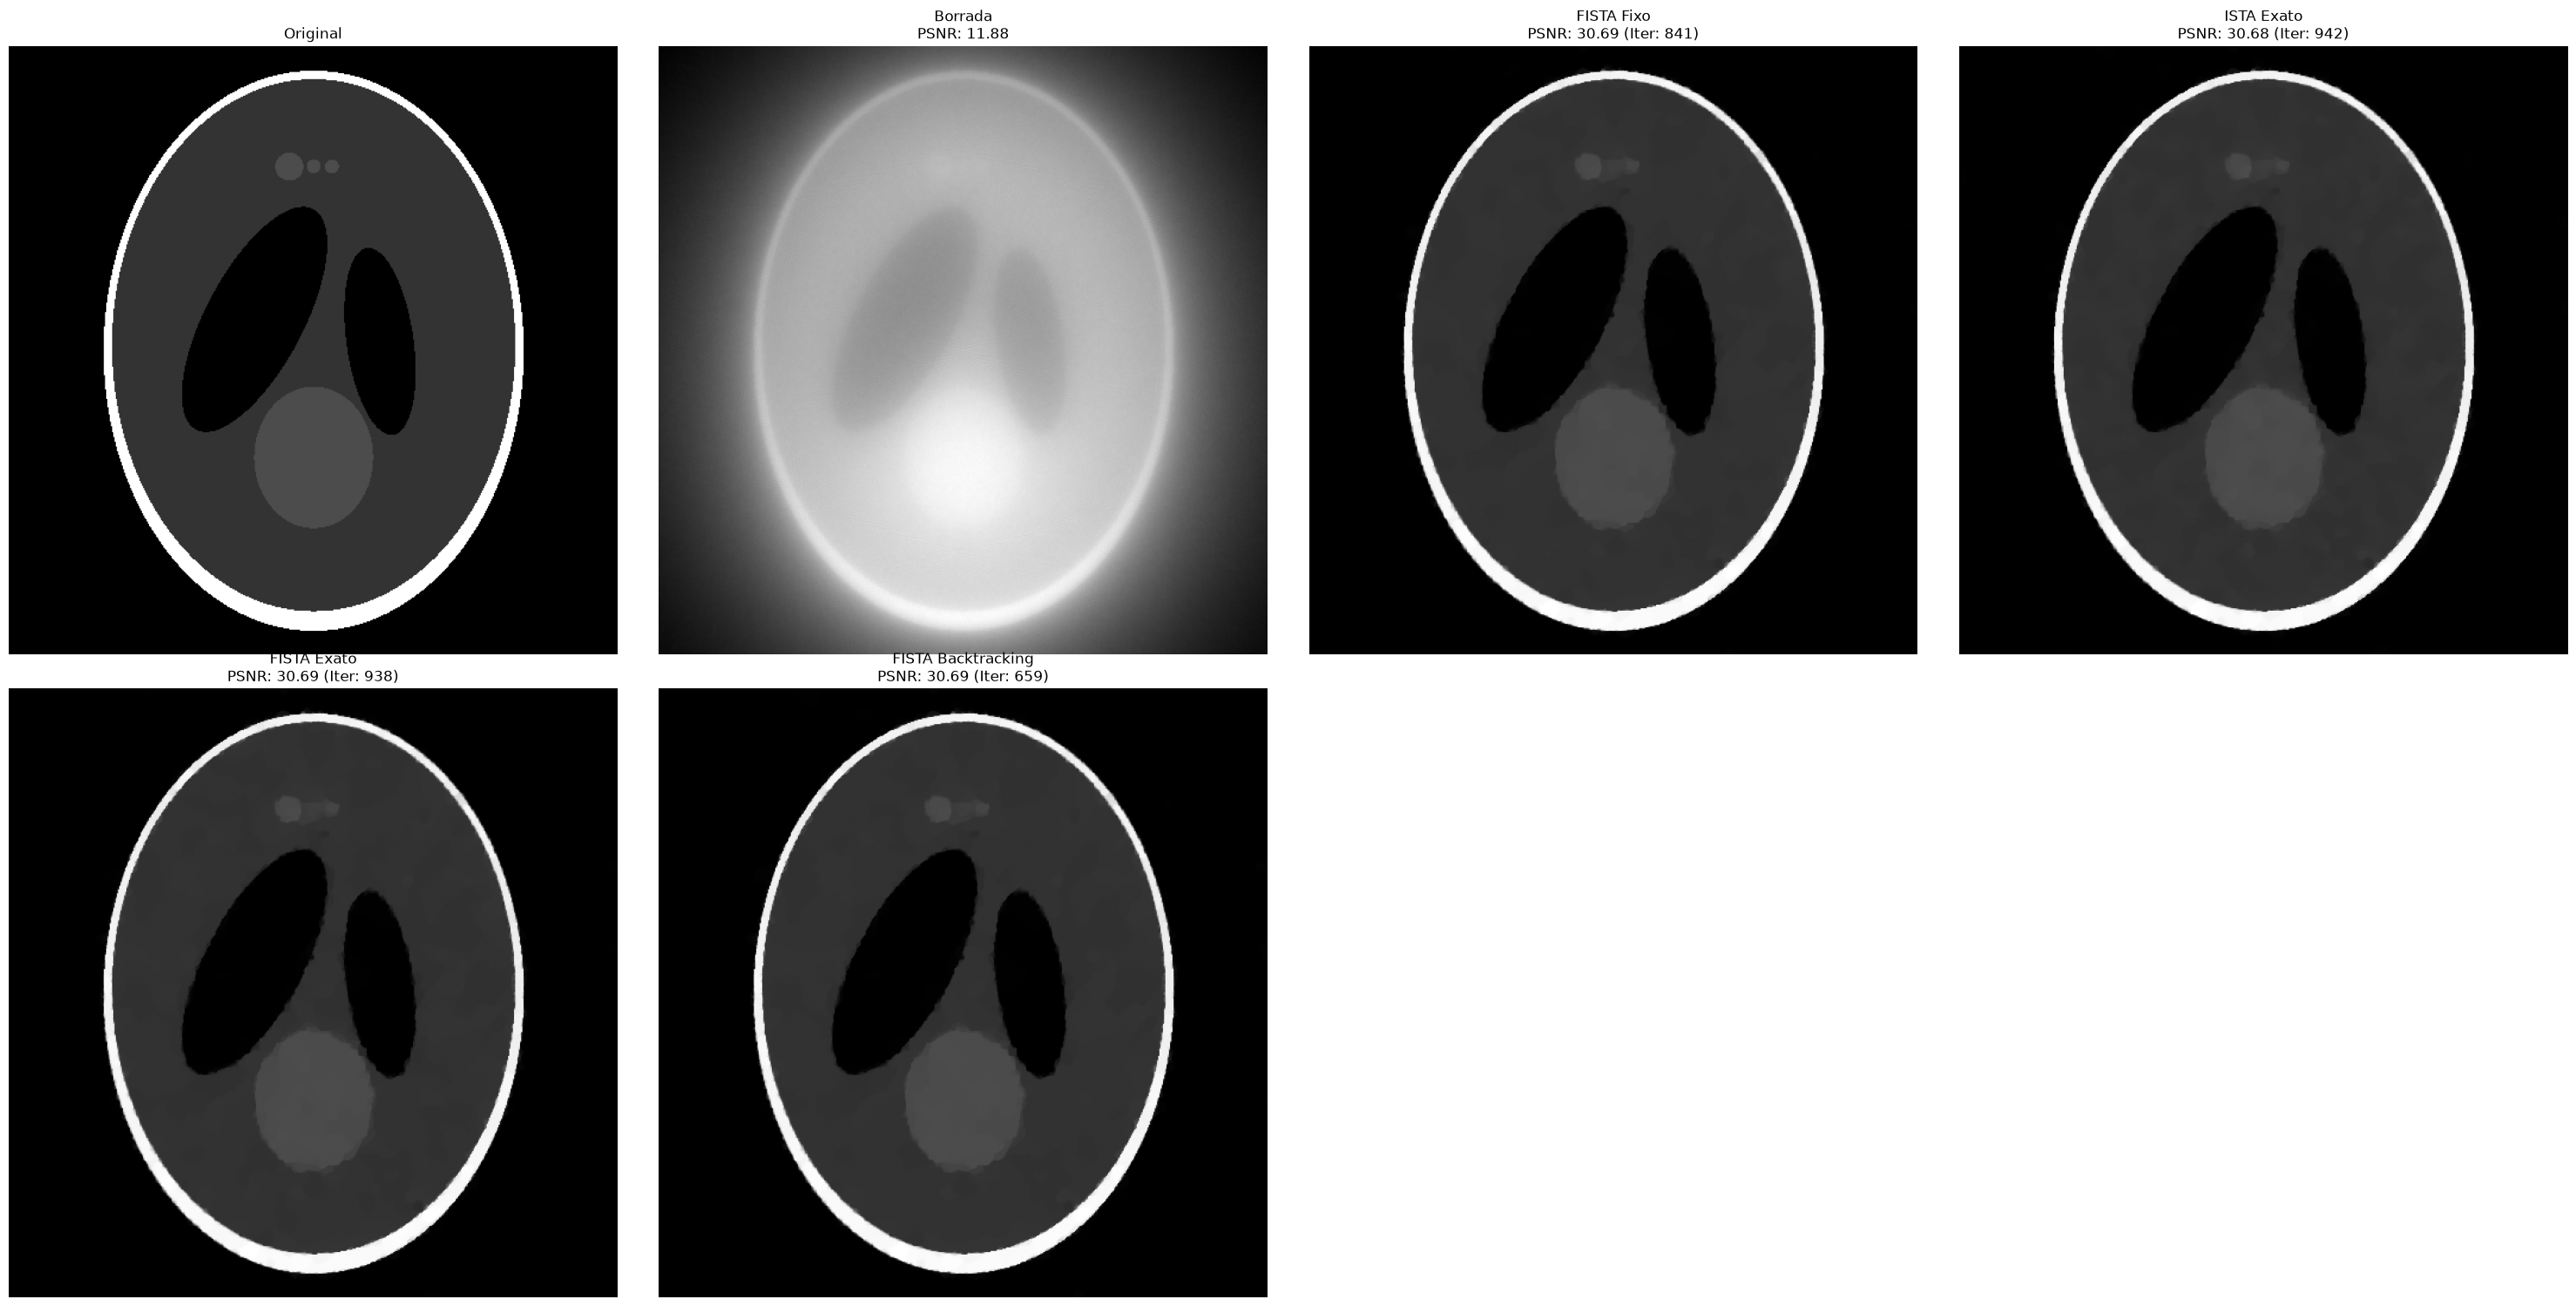

In [16]:
## vendo as melhores iterações de cada método e nao a ultima

plt.figure( figsize = ( 30, 15 ) )

names = [ "FISTA Fixo", "ISTA Exato", "FISTA Exato", "FISTA Backtracking" ]

plt.subplot( 2, 4, 1 )
plt.imshow( img.cpu().numpy(), cmap = 'gray' )
plt.title( "Original" )
plt.axis( "off" )

p_b = get_metrics( img.cpu().numpy(), b.cpu().numpy() )
plt.subplot( 2, 4, 2 )
plt.imshow( radon_transpose( b ).cpu().numpy(), cmap = 'gray' )
plt.title( f"Borrada\nPSNR: {p_b:.2f}" )
plt.axis( "off" )

for i, name in enumerate( names, start = 3 ):
    # 1. Descobre a iteração que gerou o menor valor da função objetivo
    idx_min = np.argmin( results[ name ][ "function_values" ] )
    
    # 2. Puxa a imagem exatamente dessa iteração ótima
    res_img = results[ name ][ "iters" ][ idx_min ].detach().cpu().numpy()
    
    p = get_metrics( img.cpu().numpy(), res_img )
    
    plt.subplot( 2, 4, i )
    plt.imshow( res_img, cmap = 'gray' )
    
    plt.title( f"{name}\nPSNR: {p:.2f} (Iter: {idx_min})" )
    plt.axis( "off" )

plt.tight_layout()
plt.show()

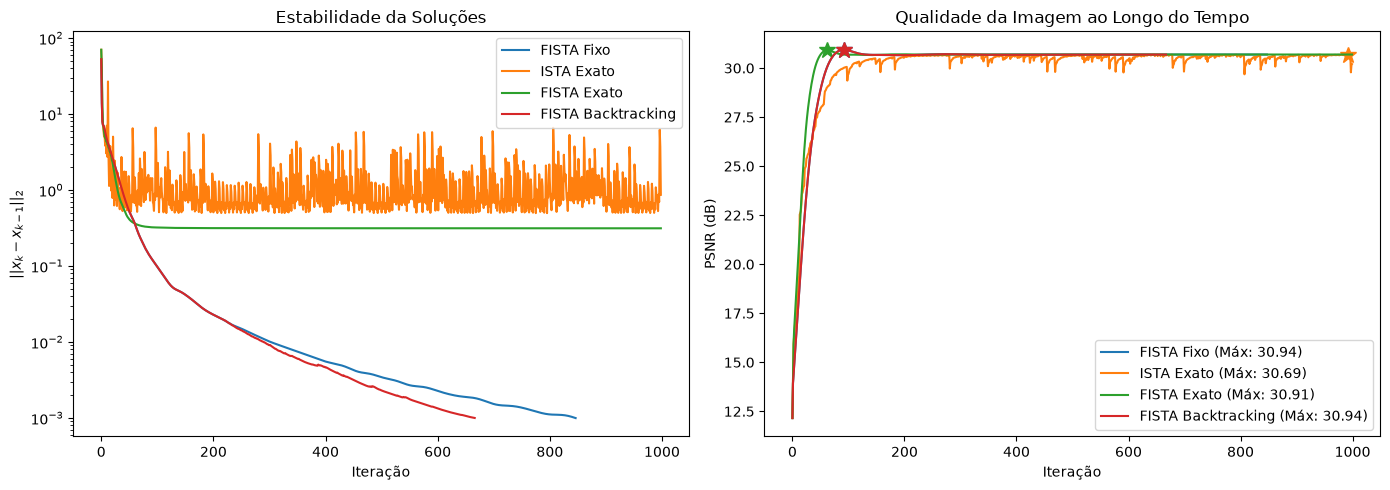

In [17]:
plt.figure( figsize = ( 14, 5 ) )

# 1. Distância entre iterações ||xk - xk-1||
plt.subplot( 1, 2, 1 )
for name in names:
    iters_list = results[ name ][ "iters" ]
    diffs = [ torch.linalg.norm( iters_list[i] - iters_list[i-1] ).item() for i in range( 1, len( iters_list ) ) ]
    
    plt.semilogy( diffs, label = name )

plt.xlabel( "Iteração" )
plt.ylabel( "$||x_k - x_{k-1}||_2$" )
plt.title( "Estabilidade da Soluções" )
plt.legend()

# 2. PSNR vs Iterações
plt.subplot( 1, 2, 2 )
img_np = img.cpu().numpy()

for name in names:
    iters_list = results[ name ][ "iters" ]
    
    psnr_vals = [ get_metrics( img_np, x.detach().cpu().numpy() ) for x in iters_list ] 
    iter_steps = np.arange( 0, len( iters_list ) )
    
    max_psnr = np.max( psnr_vals )
    idx_max = np.argmax( psnr_vals )
    
    line = plt.plot( iter_steps, psnr_vals, label = f"{name} (Máx: {max_psnr:.2f})" )[0]
    
    plt.plot( iter_steps[idx_max], max_psnr, marker = '*', markersize = 12, color = line.get_color() )

plt.xlabel( "Iteração" )
plt.ylabel( "PSNR (dB)" )
plt.title( "Qualidade da Imagem ao Longo do Tempo" )
plt.legend()

plt.tight_layout()
plt.show()

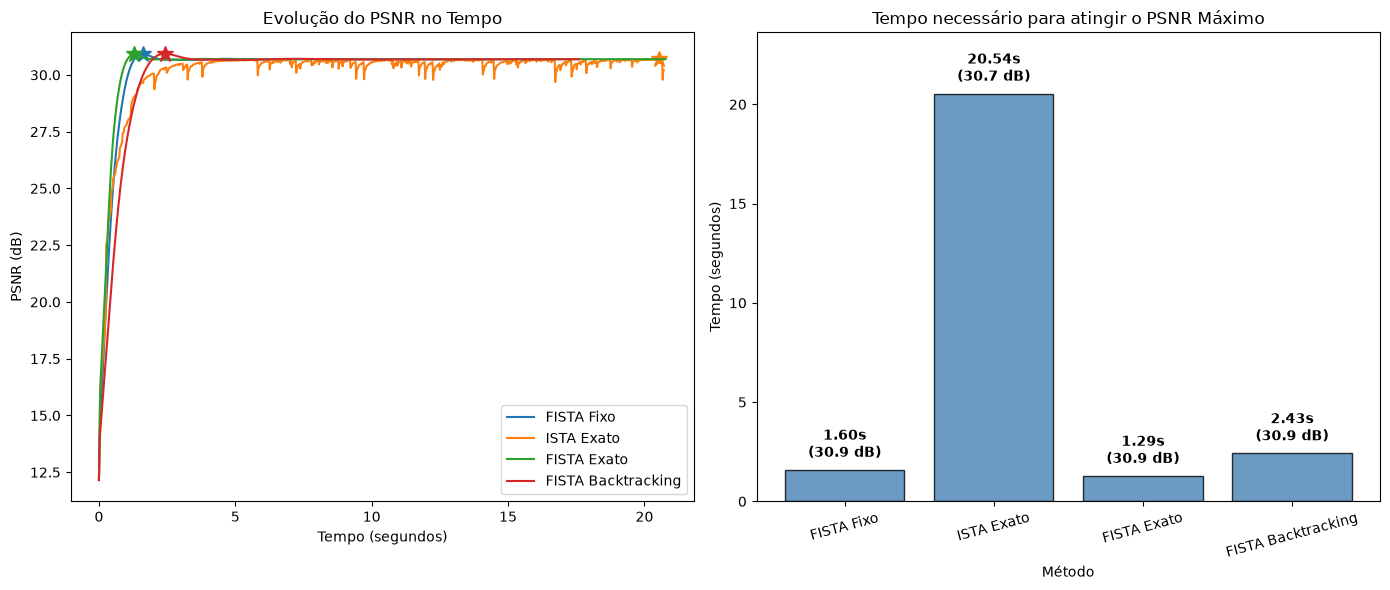

In [18]:
plt.figure( figsize = ( 14, 6 ) )

times_to_max = []
max_psnrs = []
valid_names = []

plt.subplot( 1, 2, 1 )
img_np = img.cpu().numpy()

for name in names:
    iters_list = results[ name ][ "iters" ]
    total_time = results[ name ][ "avg_time" ]
    
    psnr_vals = [ get_metrics( img_np, x.detach().cpu().numpy() ) for x in iters_list ] 
    
    times = np.linspace( 0, total_time, len( iters_list ) )
    
    max_psnr = np.max( psnr_vals )
    idx_max = np.argmax( psnr_vals )
    time_to_max = times[ idx_max ]
    
    times_to_max.append( time_to_max )
    max_psnrs.append( max_psnr )
    valid_names.append( name )
    
    line = plt.plot( times, psnr_vals, label = f"{name}" )[0]
    
    plt.plot( time_to_max, max_psnr, marker = '*', markersize = 12, color = line.get_color() )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "PSNR (dB)" )
plt.title( "Evolução do PSNR no Tempo" )
plt.legend()

plt.subplot( 1, 2, 2 )

bars = plt.bar( valid_names, times_to_max, color = 'steelblue', edgecolor = 'black', alpha = 0.8 )

for bar, psnr_val, t_max in zip( bars, max_psnrs, times_to_max ):
    yval = bar.get_height()
    plt.text( bar.get_x() + bar.get_width()/2, yval + ( 0.02 * max(times_to_max) ), 
              f"{t_max:.2f}s\n({psnr_val:.1f} dB)", 
              ha = 'center', va = 'bottom', fontsize = 10, fontweight = 'bold' )

plt.xlabel( "Método" )
plt.ylabel( "Tempo (segundos)" )
plt.title( "Tempo necessário para atingir o PSNR Máximo" )
plt.xticks( rotation = 15 )

plt.ylim( 0, max( times_to_max ) * 1.15 )

plt.tight_layout()
plt.show()

# FISTA Backtracking com ISTA e FISTA Passo Exato

## E se usarmos um parâmetro de regularização maior?


In [10]:
step = 0.2
gamma = 0.01
x0 = torch.zeros_like( b )
prox = Algorithms.prox_tv
tol = 1.0e-3
max_iter = 999
kwargs = {'max_iter_tv' : 15, 
          'L' : L, 
          'LT' : LT, 
          'proj_P' : Algorithms.proj_P,
          'A' : radon}


In [11]:
methods = {
    "FISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_fixo(f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "ISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.ista_exato( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "FISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_exato( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
}

F_obj = lambda x: f( x ) + gamma * g( x )

results = compare_methods( 
    methods = methods, 
    f = f, 
    F_obj = F_obj,
    grad_f = grad_f, 
    prox = prox, 
    x0 = x0, 
    gamma = gamma, 
    max_iter = max_iter, 
    tol = tol, 
    **kwargs 
)

F_star = min( [ min( res['function_values'] ) for res in results.values() ] )
print( f"Menor valor F_star global: {F_star}" )

Testando FISTA Fixo (5 execuções)...
FISTA Fixo: 13.2402s ± 0.0057s ( 763 iterações )
Testando ISTA Exato (5 execuções)...
ISTA Exato: 20.6922s ± 0.0047s ( 1000 iterações )
Testando FISTA Exato (5 execuções)...
FISTA Exato: 20.7683s ± 0.0144s ( 1000 iterações )
Menor valor F_star global: 122.20954895019531


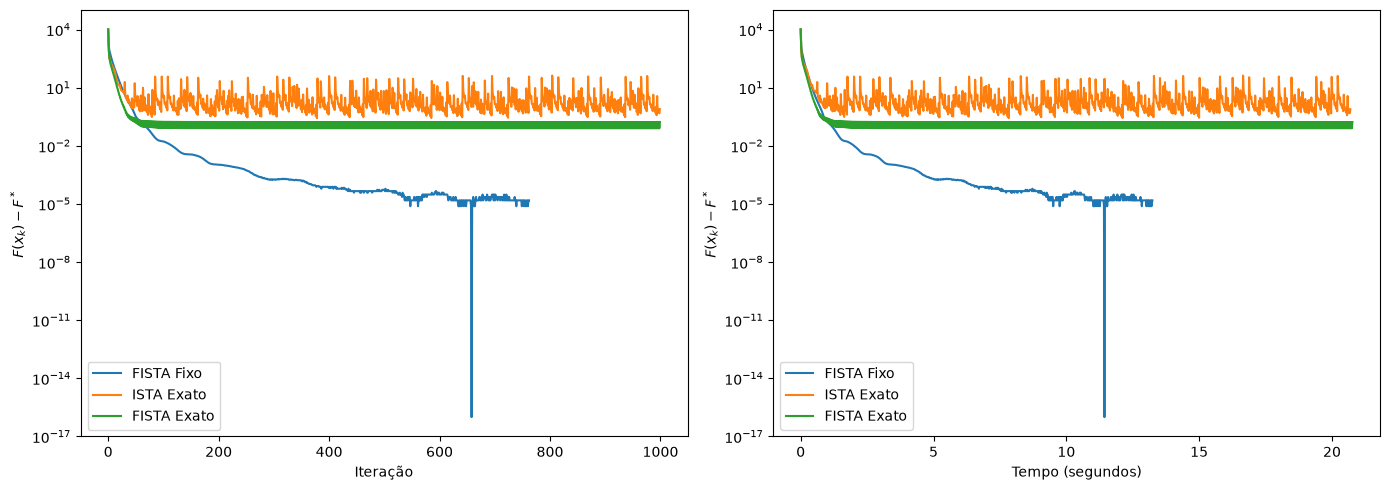

In [12]:
epsilon = 1e-16

names = list( results.keys() )

plt.figure( figsize = ( 14, 5 ) )

plt.subplot( 1, 2, 1 )
for name in names:
    vals = results[ name ][ "function_values" ]
    diff_vals = [ F - F_star + epsilon for F in vals ]
    plt.semilogy( diff_vals, label = name )

plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()
    
plt.subplot( 1, 2, 2 )
for name in names:
    vals = np.array( results[ name ][ "function_values" ] )
    diff_vals = vals - F_star + epsilon
    
    total_time = results[ name ][ "avg_time" ]
    times = np.linspace( 0, total_time, len( vals ) )
    
    plt.semilogy( times, diff_vals, label = name )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()

plt.tight_layout()
plt.show()

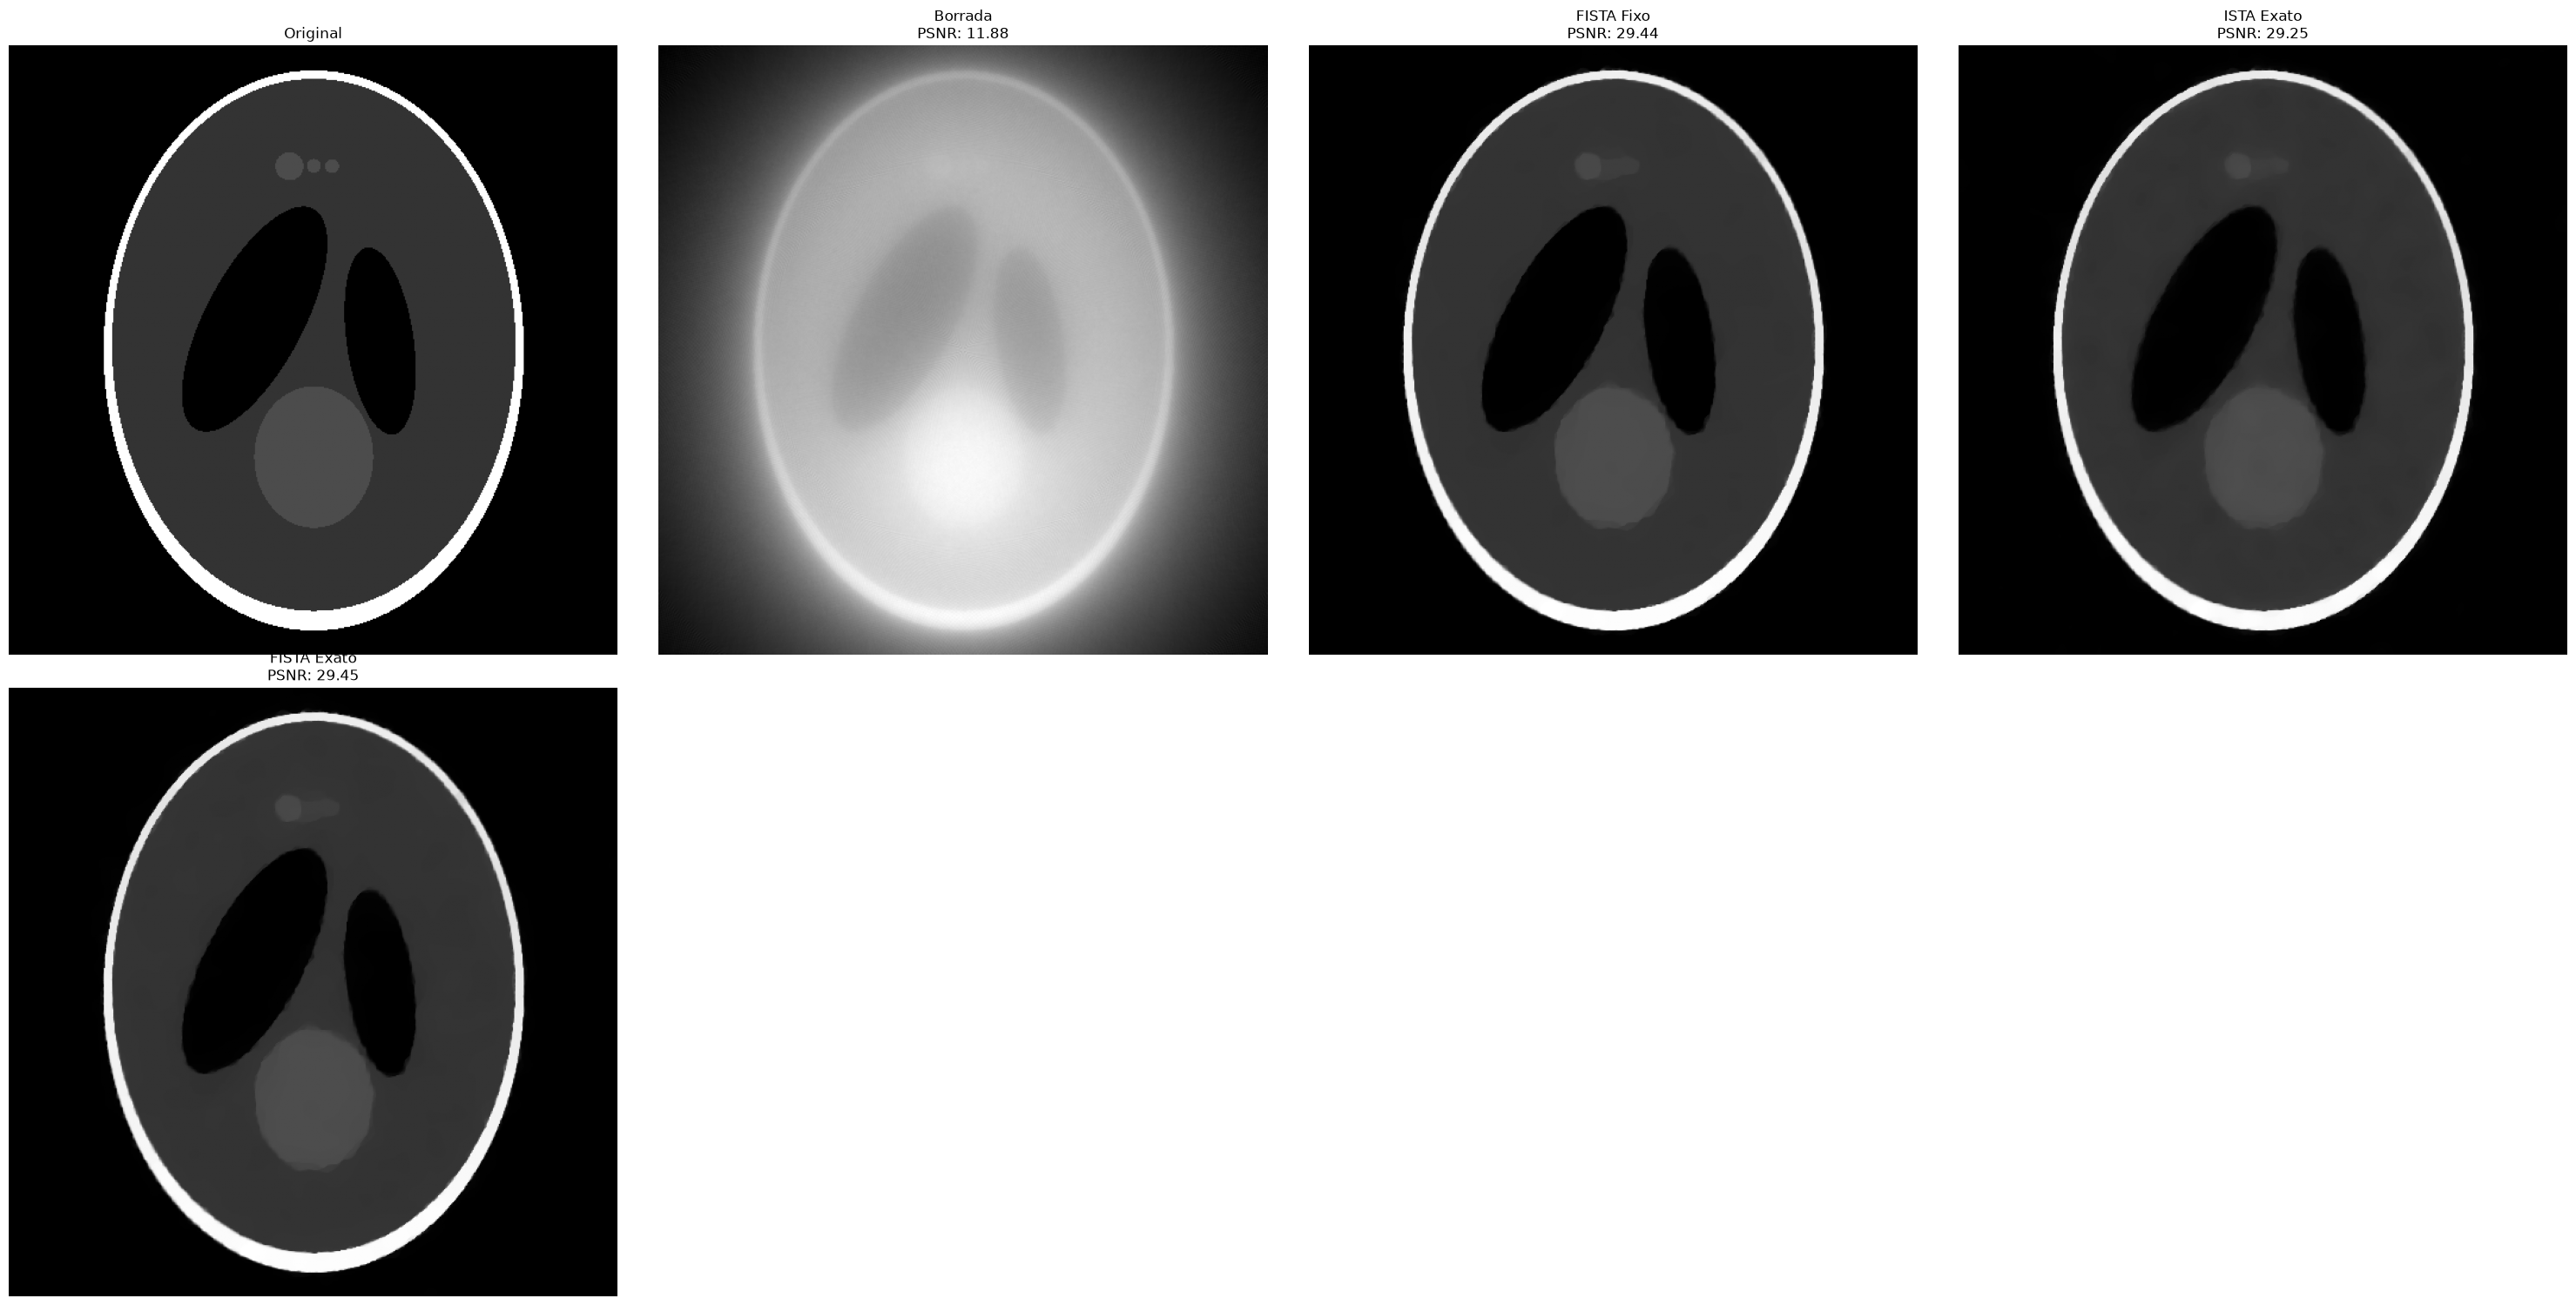

In [13]:
plt.figure( figsize = ( 30, 15 ) )

names = [ "FISTA Fixo", "ISTA Exato", "FISTA Exato" ]

plt.subplot( 2, 4, 1 )
plt.imshow( img.to( 'cpu' ).numpy(), cmap = 'gray' )
plt.title( "Original" )
plt.axis( "off" )

p_b = get_metrics( img.to( 'cpu' ).numpy(), b.to( 'cpu' ).numpy() )
plt.subplot( 2, 4, 2 )
plt.imshow( radon_transpose( b ).to( 'cpu' ).numpy(), cmap = 'gray' )
plt.title( f"Borrada\nPSNR: {p_b:.2f}" )
plt.axis( "off" )

for i, name in enumerate( names, start = 3 ):
    res_img = results[ name ][ "iters" ][ -1 ].to( 'cpu' )
    p = get_metrics( img.to( 'cpu' ).numpy(), res_img.to( 'cpu' ).numpy() )
    
    plt.subplot( 2, 4, i )
    plt.imshow( res_img, cmap = 'gray' )
    plt.title( f"{name}\nPSNR: {p:.2f}" )
    plt.axis( "off" )

plt.tight_layout()
plt.show()

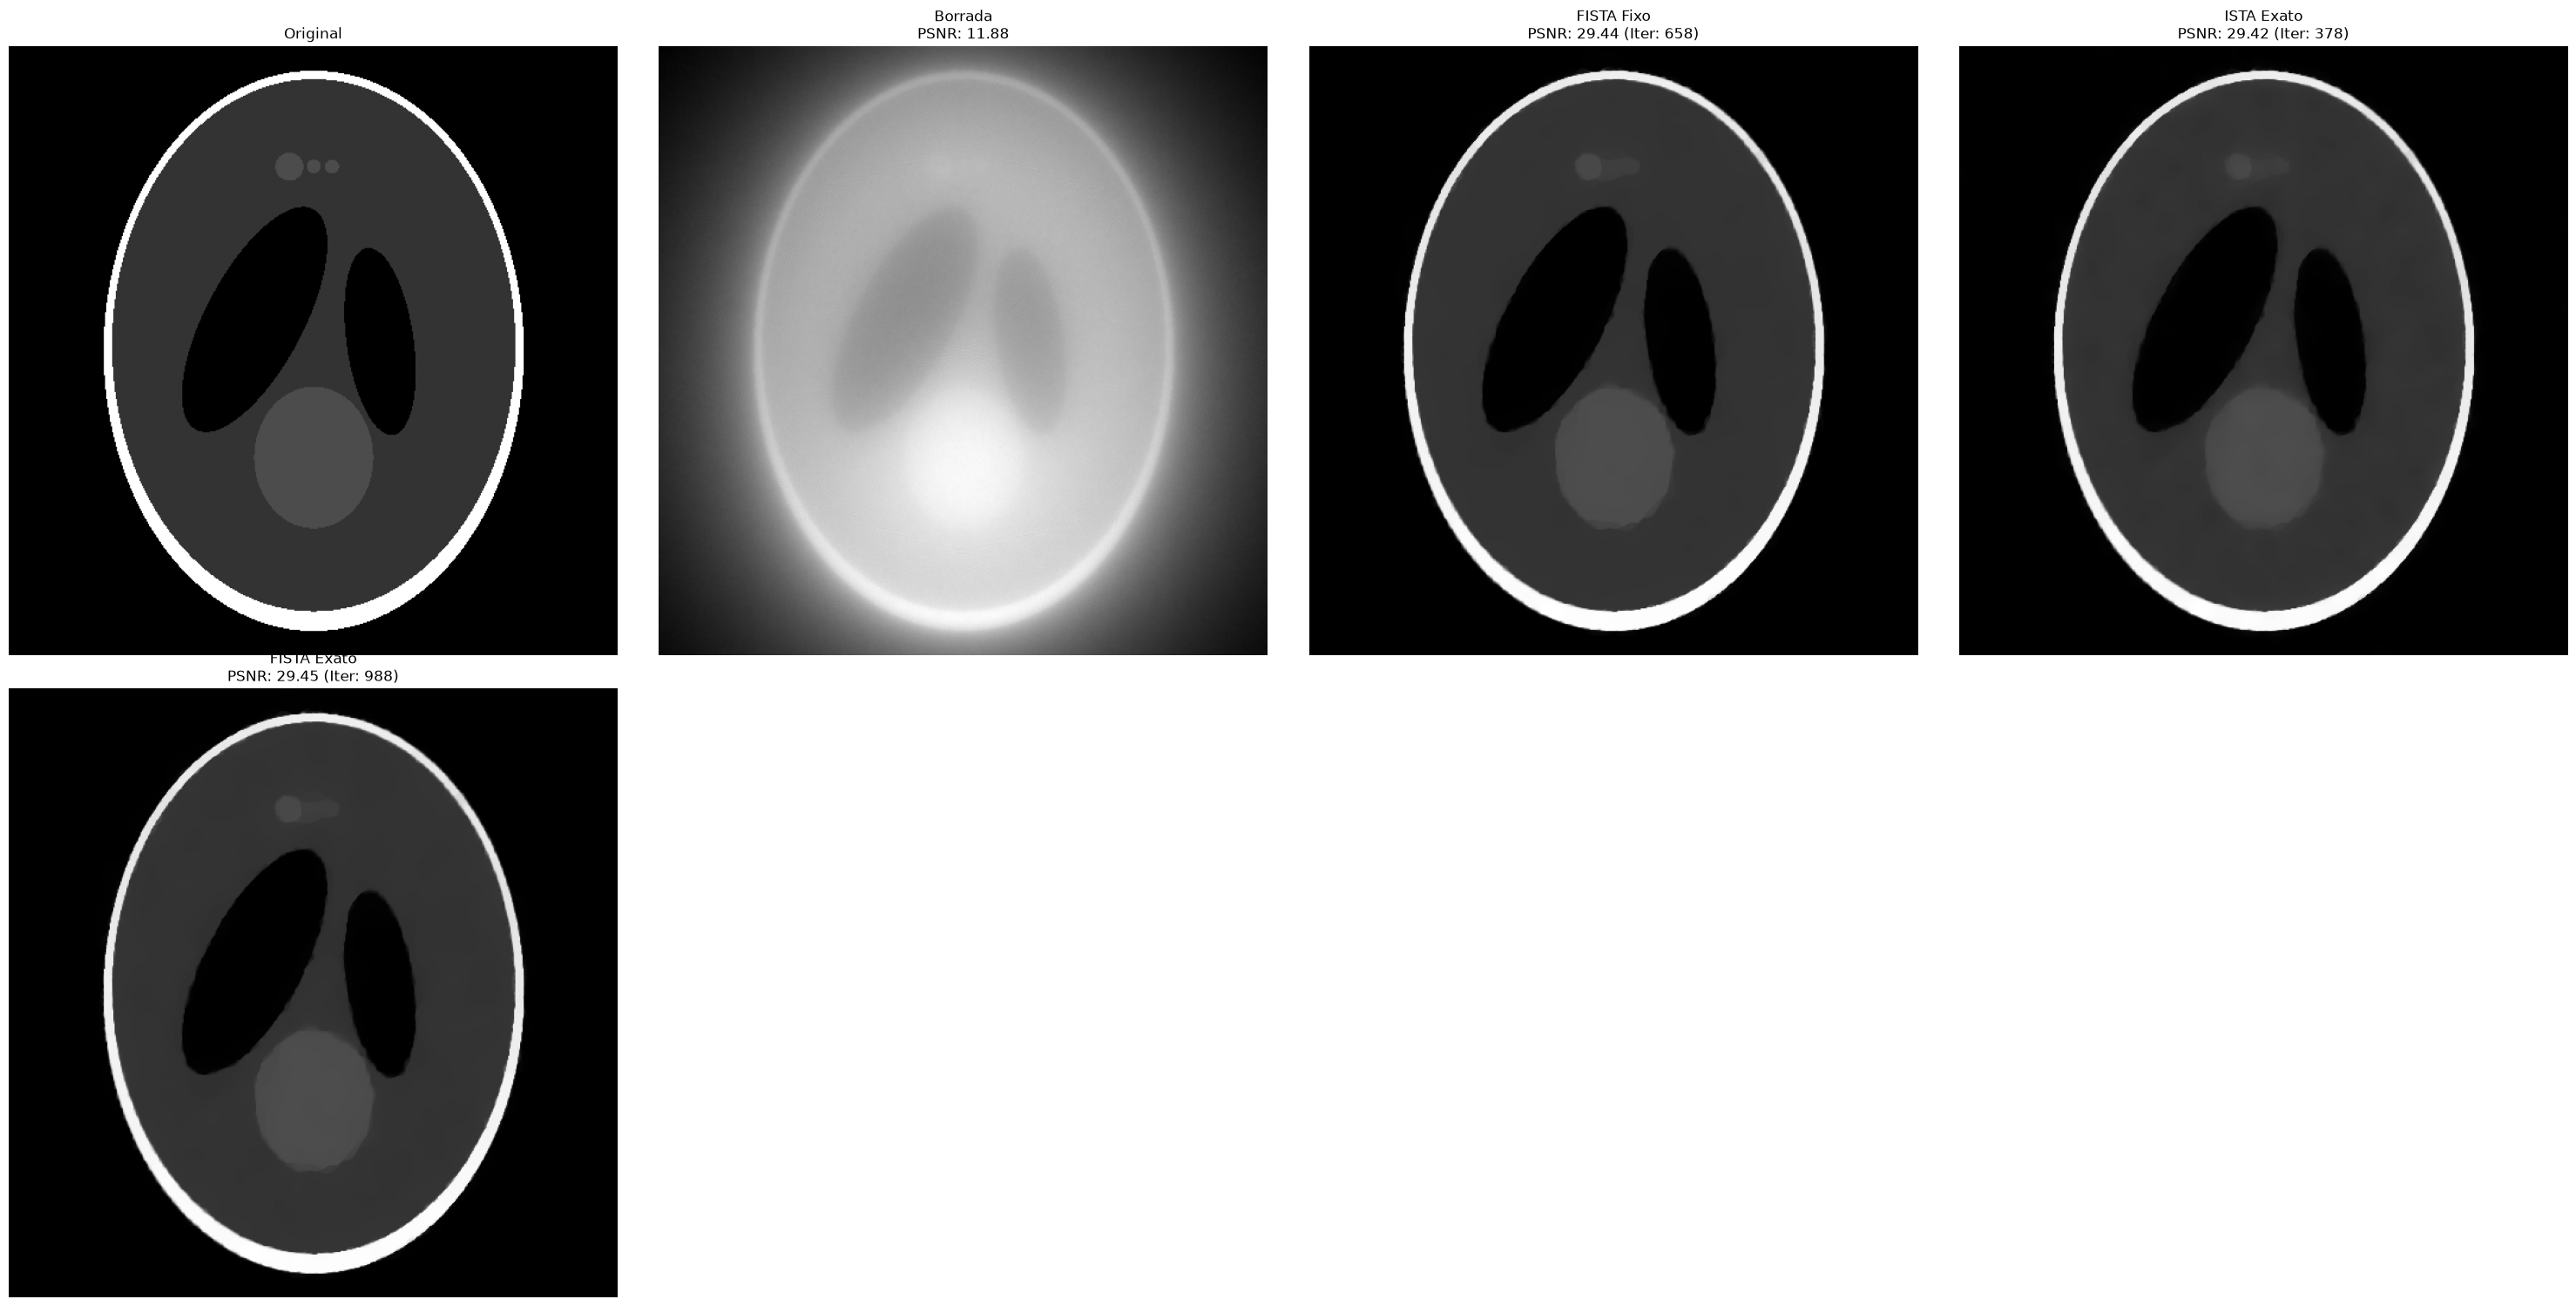

In [14]:
## vendo as melhores iterações de cada método e nao a ultima

plt.figure( figsize = ( 30, 15 ) )

plt.subplot( 2, 4, 1 )
plt.imshow( img.cpu().numpy(), cmap = 'gray' )
plt.title( "Original" )
plt.axis( "off" )

p_b = get_metrics( img.cpu().numpy(), b.cpu().numpy() )
plt.subplot( 2, 4, 2 )
plt.imshow( radon_transpose( b ).cpu().numpy(), cmap = 'gray' )
plt.title( f"Borrada\nPSNR: {p_b:.2f}" )
plt.axis( "off" )

for i, name in enumerate( names, start = 3 ):
    # 1. Descobre a iteração que gerou o menor valor da função objetivo
    idx_min = np.argmin( results[ name ][ "function_values" ] )
    
    # 2. Puxa a imagem exatamente dessa iteração ótima
    res_img = results[ name ][ "iters" ][ idx_min ].detach().cpu().numpy()
    
    p = get_metrics( img.cpu().numpy(), res_img )
    
    plt.subplot( 2, 4, i )
    plt.imshow( res_img, cmap = 'gray' )
    
    plt.title( f"{name}\nPSNR: {p:.2f} (Iter: {idx_min})" )
    plt.axis( "off" )

plt.tight_layout()
plt.show()

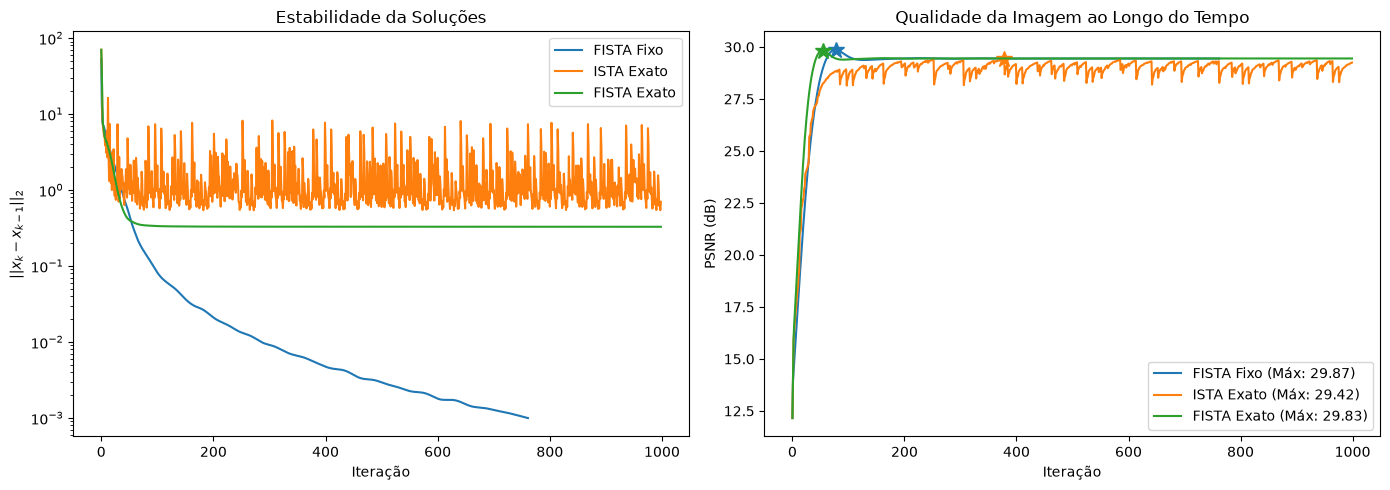

In [15]:
plt.figure( figsize = ( 14, 5 ) )

# 1. Distância entre iterações ||xk - xk-1||
plt.subplot( 1, 2, 1 )
for name in names:
    iters_list = results[ name ][ "iters" ]
    diffs = [ torch.linalg.norm( iters_list[i] - iters_list[i-1] ).item() for i in range( 1, len( iters_list ) ) ]
    
    plt.semilogy( diffs, label = name )

plt.xlabel( "Iteração" )
plt.ylabel( "$||x_k - x_{k-1}||_2$" )
plt.title( "Estabilidade da Soluções" )
plt.legend()

# 2. PSNR vs Iterações
plt.subplot( 1, 2, 2 )
img_np = img.cpu().numpy()

for name in names:
    iters_list = results[ name ][ "iters" ]
    
    psnr_vals = [ get_metrics( img_np, x.detach().cpu().numpy() ) for x in iters_list ] 
    iter_steps = np.arange( 0, len( iters_list ) )
    
    max_psnr = np.max( psnr_vals )
    idx_max = np.argmax( psnr_vals )
    
    line = plt.plot( iter_steps, psnr_vals, label = f"{name} (Máx: {max_psnr:.2f})" )[0]
    
    plt.plot( iter_steps[idx_max], max_psnr, marker = '*', markersize = 12, color = line.get_color() )

plt.xlabel( "Iteração" )
plt.ylabel( "PSNR (dB)" )
plt.title( "Qualidade da Imagem ao Longo do Tempo" )
plt.legend()

plt.tight_layout()
plt.show()

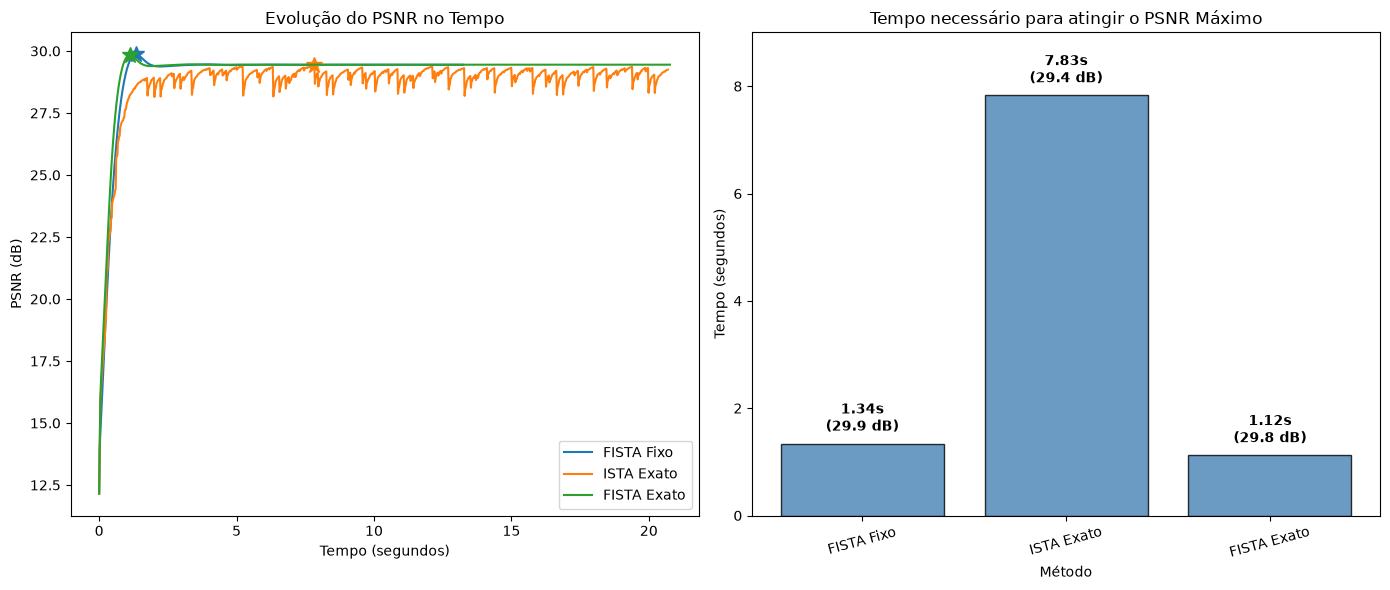

In [16]:
plt.figure( figsize = ( 14, 6 ) )

times_to_max = []
max_psnrs = []
valid_names = []

plt.subplot( 1, 2, 1 )
img_np = img.cpu().numpy()

for name in names:
    iters_list = results[ name ][ "iters" ]
    total_time = results[ name ][ "avg_time" ]
    
    psnr_vals = [ get_metrics( img_np, x.detach().cpu().numpy() ) for x in iters_list ] 
    
    times = np.linspace( 0, total_time, len( iters_list ) )
    
    max_psnr = np.max( psnr_vals )
    idx_max = np.argmax( psnr_vals )
    time_to_max = times[ idx_max ]
    
    times_to_max.append( time_to_max )
    max_psnrs.append( max_psnr )
    valid_names.append( name )
    
    line = plt.plot( times, psnr_vals, label = f"{name}" )[0]
    
    plt.plot( time_to_max, max_psnr, marker = '*', markersize = 12, color = line.get_color() )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "PSNR (dB)" )
plt.title( "Evolução do PSNR no Tempo" )
plt.legend()

plt.subplot( 1, 2, 2 )

bars = plt.bar( valid_names, times_to_max, color = 'steelblue', edgecolor = 'black', alpha = 0.8 )

for bar, psnr_val, t_max in zip( bars, max_psnrs, times_to_max ):
    yval = bar.get_height()
    plt.text( bar.get_x() + bar.get_width()/2, yval + ( 0.02 * max(times_to_max) ), 
              f"{t_max:.2f}s\n({psnr_val:.1f} dB)", 
              ha = 'center', va = 'bottom', fontsize = 10, fontweight = 'bold' )

plt.xlabel( "Método" )
plt.ylabel( "Tempo (segundos)" )
plt.title( "Tempo necessário para atingir o PSNR Máximo" )
plt.xticks( rotation = 15 )

plt.ylim( 0, max( times_to_max ) * 1.15 )

plt.tight_layout()
plt.show()

## E se a tolerância for menor?


In [10]:
step = 0.2
gamma = 0.005
x0 = torch.zeros_like( b )
prox = Algorithms.prox_tv
tol = 1.0e-2
max_iter = 999
kwargs = {'max_iter_tv' : 15, 
          'L' : L, 
          'LT' : LT, 
          'proj_P' : Algorithms.proj_P,
          'A' : radon}


In [11]:
methods = {
    "FISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_fixo(f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "ISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.ista_exato( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "FISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_exato( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
}


F_obj = lambda x: f( x ) + gamma * g( x )

results = compare_methods( 
    methods = methods, 
    f = f, 
    F_obj = F_obj,
    grad_f = grad_f, 
    prox = prox, 
    x0 = x0, 
    gamma = gamma, 
    max_iter = max_iter, 
    tol = tol, 
    **kwargs 
)

F_star = min( [ min( res['function_values'] ) for res in results.values() ] )
print( f"Menor valor F_star global: {F_star}" )

Testando FISTA Fixo (5 execuções)...
FISTA Fixo: 5.2698s ± 0.0104s ( 304 iterações )
Testando ISTA Exato (5 execuções)...
ISTA Exato: 20.6969s ± 0.0281s ( 1000 iterações )
Testando FISTA Exato (5 execuções)...
FISTA Exato: 20.7860s ± 0.0149s ( 1000 iterações )
Menor valor F_star global: 109.564453125


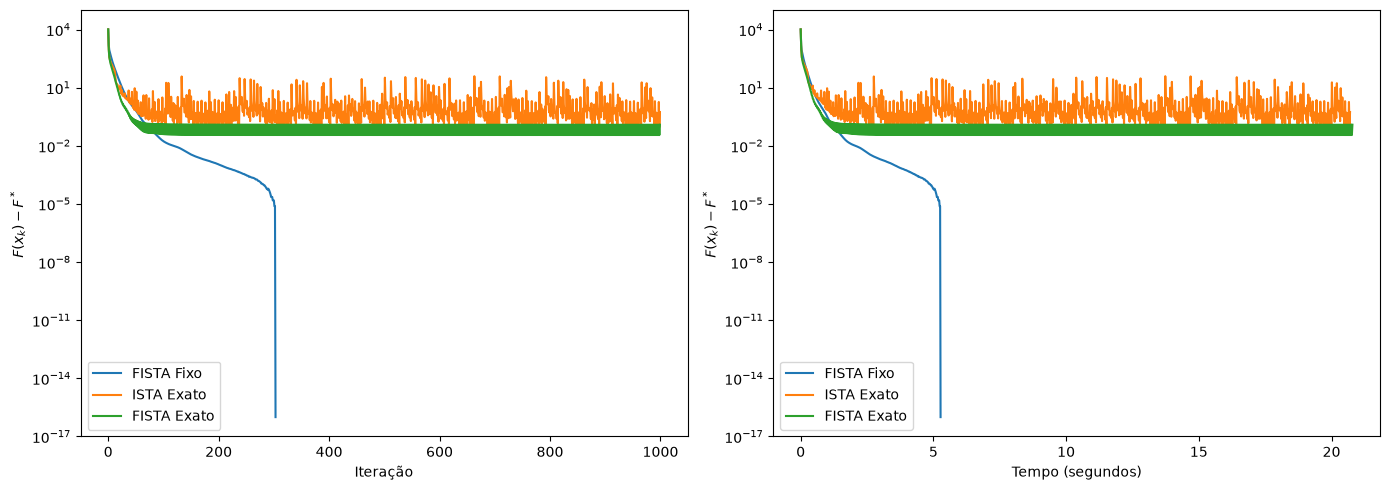

In [12]:
epsilon = 1e-16

names = list( results.keys() )

plt.figure( figsize = ( 14, 5 ) )

plt.subplot( 1, 2, 1 )
for name in names:
    vals = results[ name ][ "function_values" ]
    diff_vals = [ F - F_star + epsilon for F in vals ]
    plt.semilogy( diff_vals, label = name )

plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()

plt.subplot( 1, 2, 2 )
for name in names:
    vals = np.array( results[ name ][ "function_values" ] )
    diff_vals = vals - F_star + epsilon
    
    total_time = results[ name ][ "avg_time" ]
    times = np.linspace( 0, total_time, len( vals ) )
    
    plt.semilogy( times, diff_vals, label = name )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()

plt.tight_layout()
plt.show()

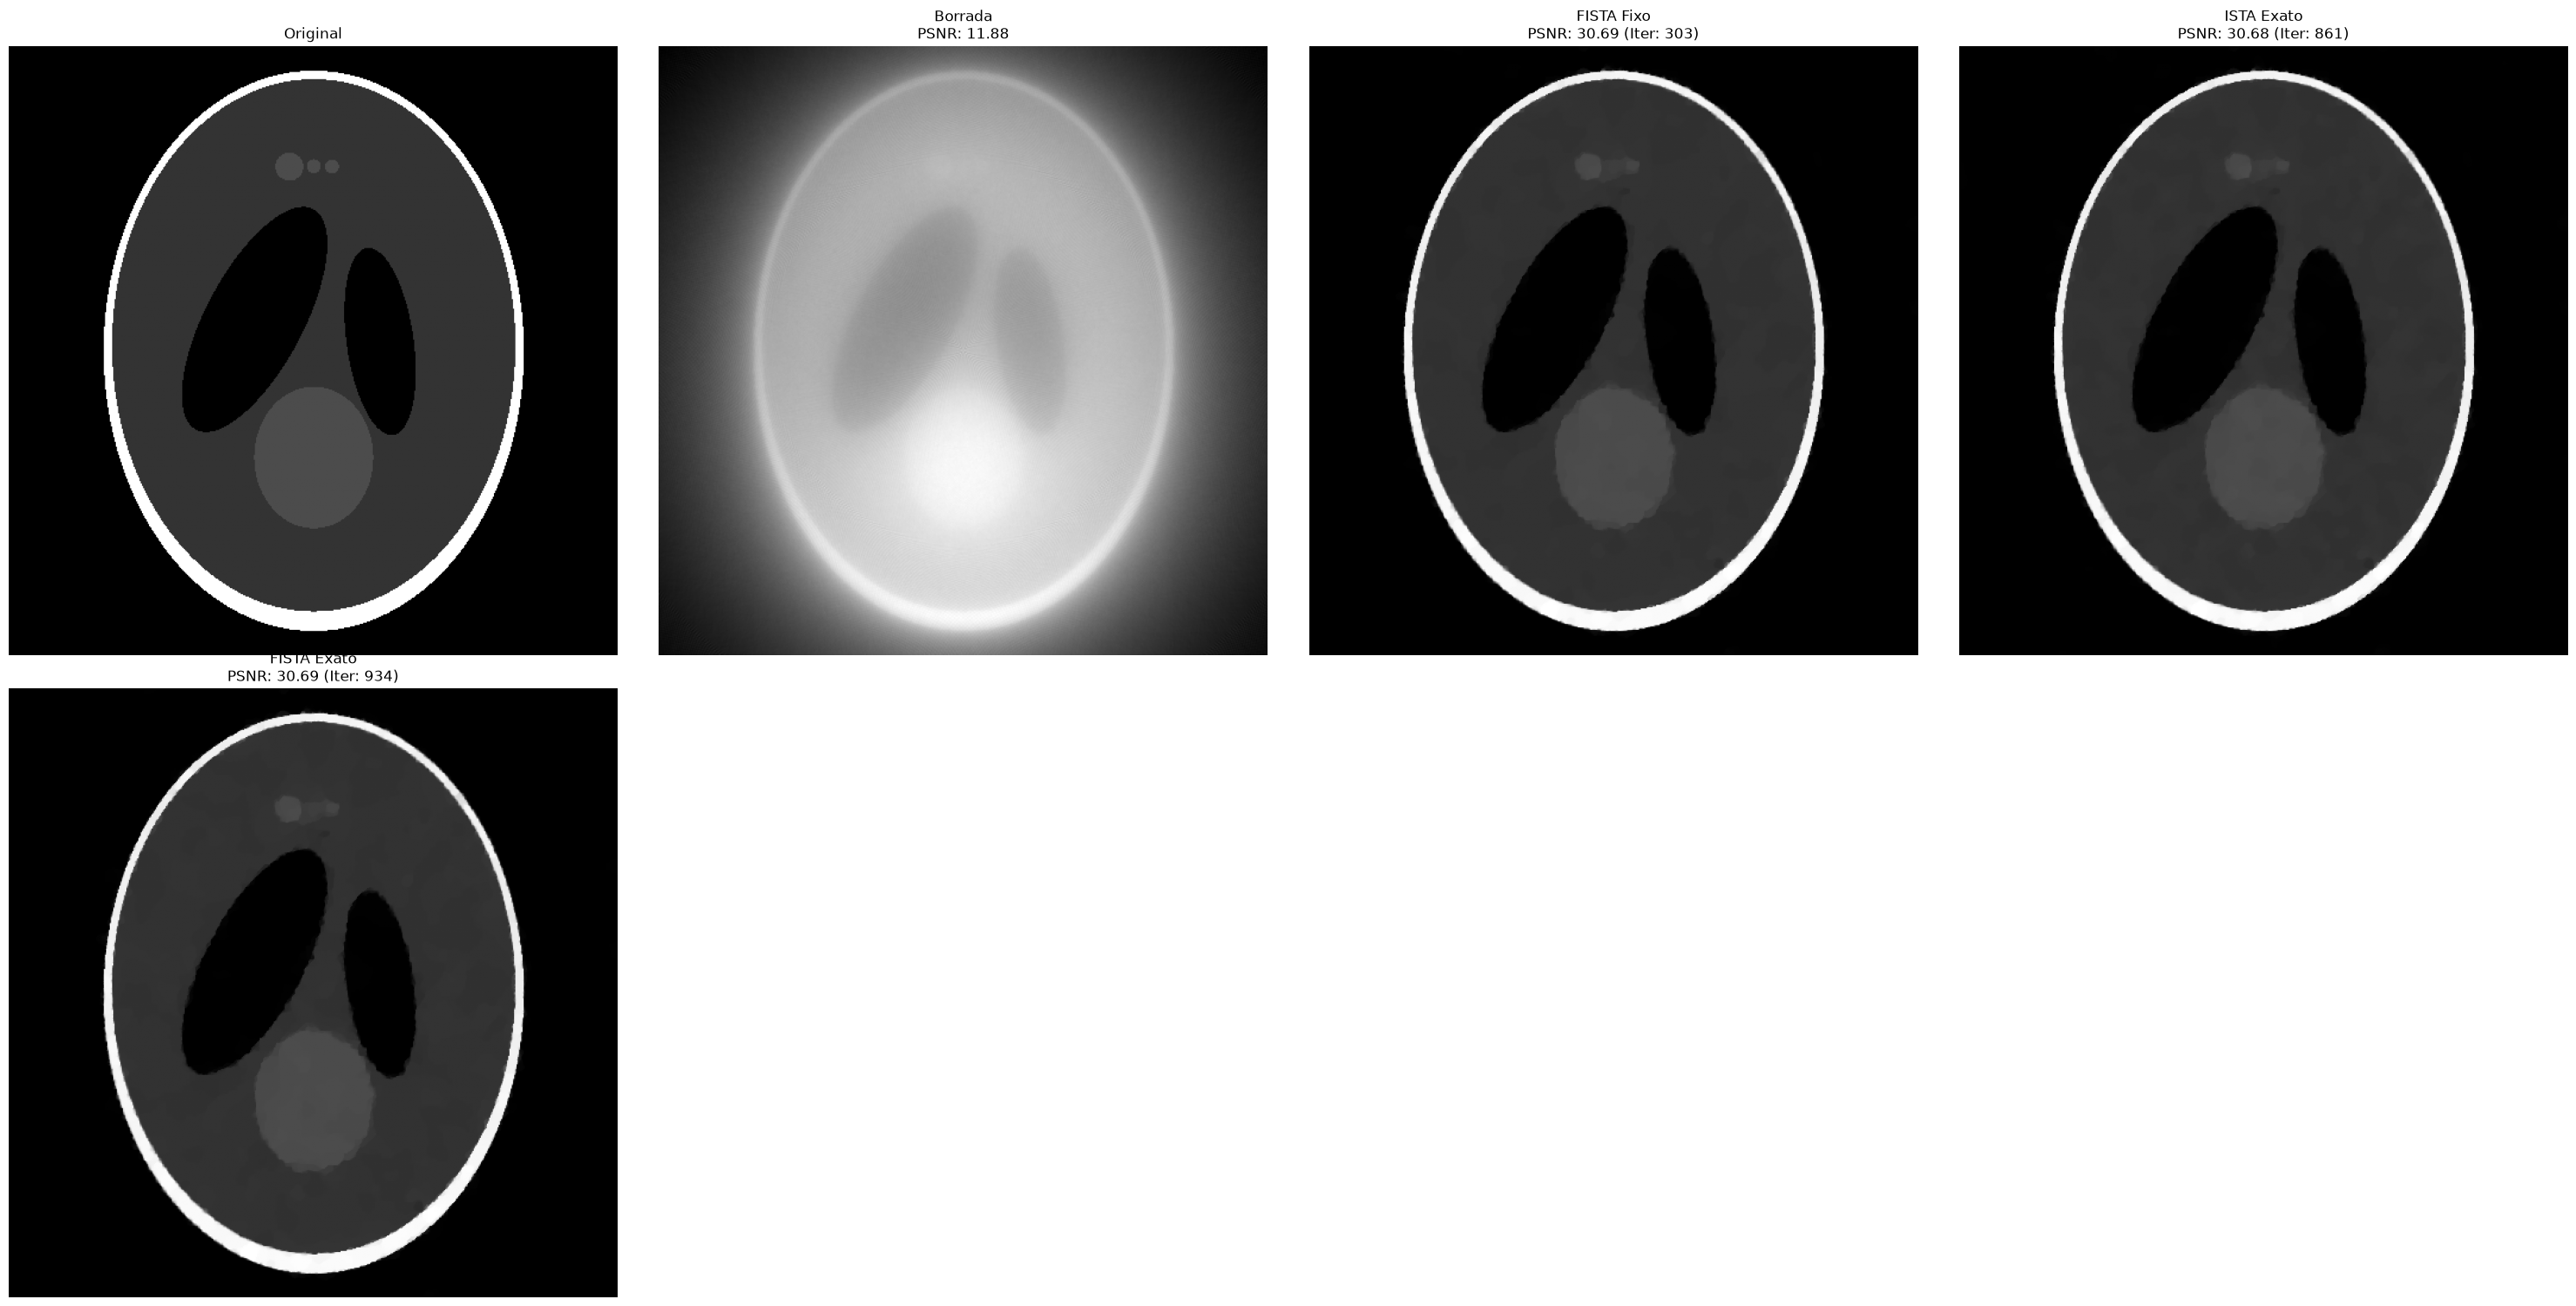

In [13]:
## vendo as melhores iterações de cada método e nao a ultima

plt.figure( figsize = ( 30, 15 ) )

plt.subplot( 2, 4, 1 )
plt.imshow( img.cpu().numpy(), cmap = 'gray' )
plt.title( "Original" )
plt.axis( "off" )

p_b = get_metrics( img.cpu().numpy(), b.cpu().numpy() )
plt.subplot( 2, 4, 2 )
plt.imshow( radon_transpose( b ).cpu().numpy(), cmap = 'gray' )
plt.title( f"Borrada\nPSNR: {p_b:.2f}" )
plt.axis( "off" )

for i, name in enumerate( names, start = 3 ):
    # 1. Descobre a iteração que gerou o menor valor da função objetivo
    idx_min = np.argmin( results[ name ][ "function_values" ] )
    
    # 2. Puxa a imagem exatamente dessa iteração ótima
    res_img = results[ name ][ "iters" ][ idx_min ].detach().cpu().numpy()
    
    p = get_metrics( img.cpu().numpy(), res_img )
    
    plt.subplot( 2, 4, i )
    plt.imshow( res_img, cmap = 'gray' )
    
    plt.title( f"{name}\nPSNR: {p:.2f} (Iter: {idx_min})" )
    plt.axis( "off" )

plt.tight_layout()
plt.show()

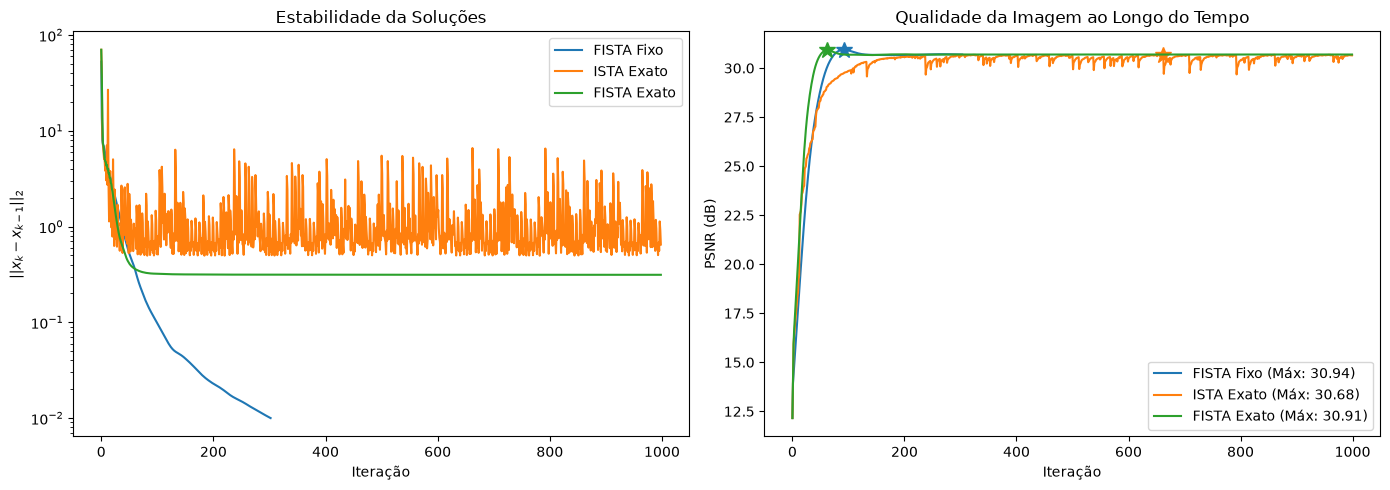

In [14]:
plt.figure( figsize = ( 14, 5 ) )

# 1. Distância entre iterações ||xk - xk-1||
plt.subplot( 1, 2, 1 )
for name in names:
    iters_list = results[ name ][ "iters" ]
    diffs = [ torch.linalg.norm( iters_list[i] - iters_list[i-1] ).item() for i in range( 1, len( iters_list ) ) ]
    
    plt.semilogy( diffs, label = name )

plt.xlabel( "Iteração" )
plt.ylabel( "$||x_k - x_{k-1}||_2$" )
plt.title( "Estabilidade da Soluções" )
plt.legend()

# 2. PSNR vs Iterações
plt.subplot( 1, 2, 2 )
img_np = img.cpu().numpy()

for name in names:
    iters_list = results[ name ][ "iters" ]
    
    psnr_vals = [ get_metrics( img_np, x.detach().cpu().numpy() ) for x in iters_list ] 
    iter_steps = np.arange( 0, len( iters_list ) )
    
    max_psnr = np.max( psnr_vals )
    idx_max = np.argmax( psnr_vals )
    
    line = plt.plot( iter_steps, psnr_vals, label = f"{name} (Máx: {max_psnr:.2f})" )[0]
    
    plt.plot( iter_steps[idx_max], max_psnr, marker = '*', markersize = 12, color = line.get_color() )

plt.xlabel( "Iteração" )
plt.ylabel( "PSNR (dB)" )
plt.title( "Qualidade da Imagem ao Longo do Tempo" )
plt.legend()

plt.tight_layout()
plt.show()

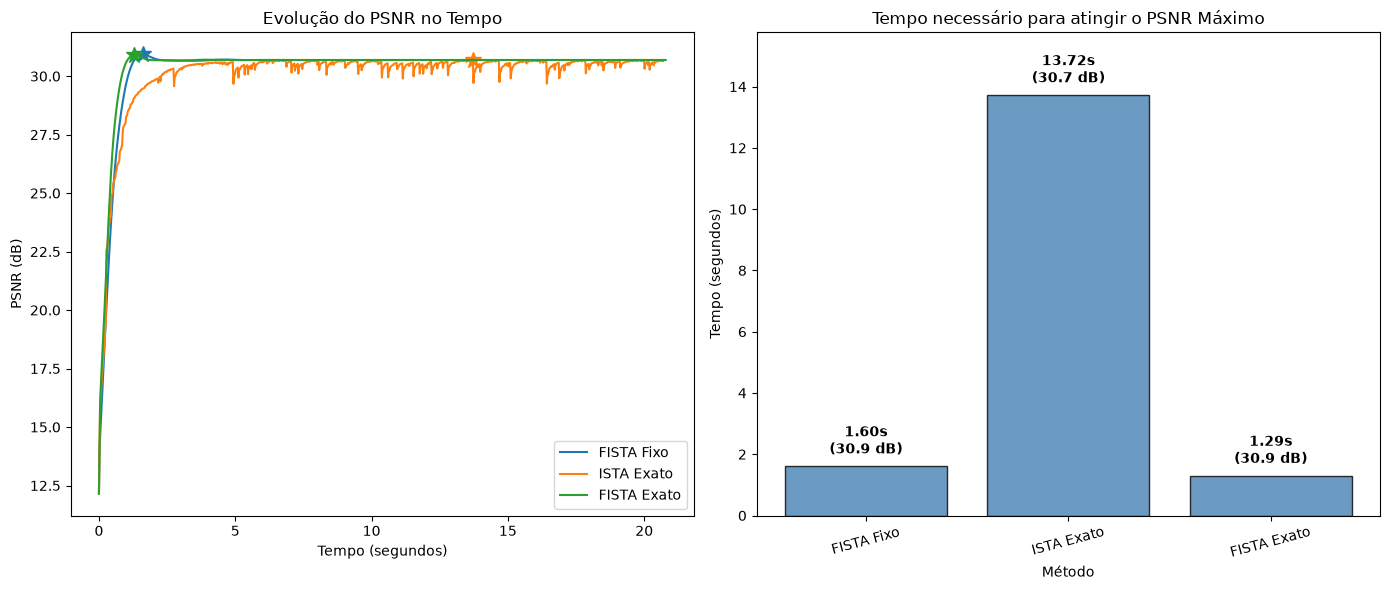

In [15]:
plt.figure( figsize = ( 14, 6 ) )

times_to_max = []
max_psnrs = []
valid_names = []

plt.subplot( 1, 2, 1 )
img_np = img.cpu().numpy()

for name in names:
    iters_list = results[ name ][ "iters" ]
    total_time = results[ name ][ "avg_time" ]
    
    psnr_vals = [ get_metrics( img_np, x.detach().cpu().numpy() ) for x in iters_list ] 
    
    times = np.linspace( 0, total_time, len( iters_list ) )
    
    max_psnr = np.max( psnr_vals )
    idx_max = np.argmax( psnr_vals )
    time_to_max = times[ idx_max ]
    
    times_to_max.append( time_to_max )
    max_psnrs.append( max_psnr )
    valid_names.append( name )
    
    line = plt.plot( times, psnr_vals, label = f"{name}" )[0]
    
    plt.plot( time_to_max, max_psnr, marker = '*', markersize = 12, color = line.get_color() )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "PSNR (dB)" )
plt.title( "Evolução do PSNR no Tempo" )
plt.legend()

plt.subplot( 1, 2, 2 )

bars = plt.bar( valid_names, times_to_max, color = 'steelblue', edgecolor = 'black', alpha = 0.8 )

for bar, psnr_val, t_max in zip( bars, max_psnrs, times_to_max ):
    yval = bar.get_height()
    plt.text( bar.get_x() + bar.get_width()/2, yval + ( 0.02 * max(times_to_max) ), 
              f"{t_max:.2f}s\n({psnr_val:.1f} dB)", 
              ha = 'center', va = 'bottom', fontsize = 10, fontweight = 'bold' )

plt.xlabel( "Método" )
plt.ylabel( "Tempo (segundos)" )
plt.title( "Tempo necessário para atingir o PSNR Máximo" )
plt.xticks( rotation = 15 )

plt.ylim( 0, max( times_to_max ) * 1.15 )

plt.tight_layout()
plt.show()

## E se o chute inicial for $A^Tb$?

In [10]:
step = 0.2
gamma = 0.005
x0 = radon_transpose( b )
prox = Algorithms.prox_tv
tol = 1.0e-2
max_iter = 999
kwargs = {'max_iter_tv' : 15, 
          'L' : L, 
          'LT' : LT, 
          'proj_P' : Algorithms.proj_P,
          'A' : radon}


In [11]:
methods = {
    "FISTA Fixo": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_fixo(f = f, x0 = x0, grad_f = grad_f, prox = prox, step = step, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "ISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.ista_exato( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
    "FISTA Exato": lambda f, grad_f, prox, x0, gamma, max_iter, tol, **kwargs: 
        Algorithms.fista_exato( f = f, x0 = x0, grad_f = grad_f, prox = prox, gamma = gamma, max_iter = max_iter, tol = tol, **kwargs ),
}


F_obj = lambda x: f( x ) + gamma * g( x )

results = compare_methods( 
    methods = methods, 
    f = f, 
    F_obj = F_obj,
    grad_f = grad_f, 
    prox = prox, 
    x0 = x0, 
    gamma = gamma, 
    max_iter = max_iter, 
    tol = tol, 
    **kwargs 
)

F_star = min( [ min( res['function_values'] ) for res in results.values() ] )
print( f"Menor valor F_star global: {F_star}" )

Testando FISTA Fixo (5 execuções)...
FISTA Fixo: 5.2439s ± 0.0140s ( 302 iterações )
Testando ISTA Exato (5 execuções)...
ISTA Exato: 20.6946s ± 0.0086s ( 1000 iterações )
Testando FISTA Exato (5 execuções)...
FISTA Exato: 20.8555s ± 0.0533s ( 1000 iterações )
Menor valor F_star global: 109.564453125


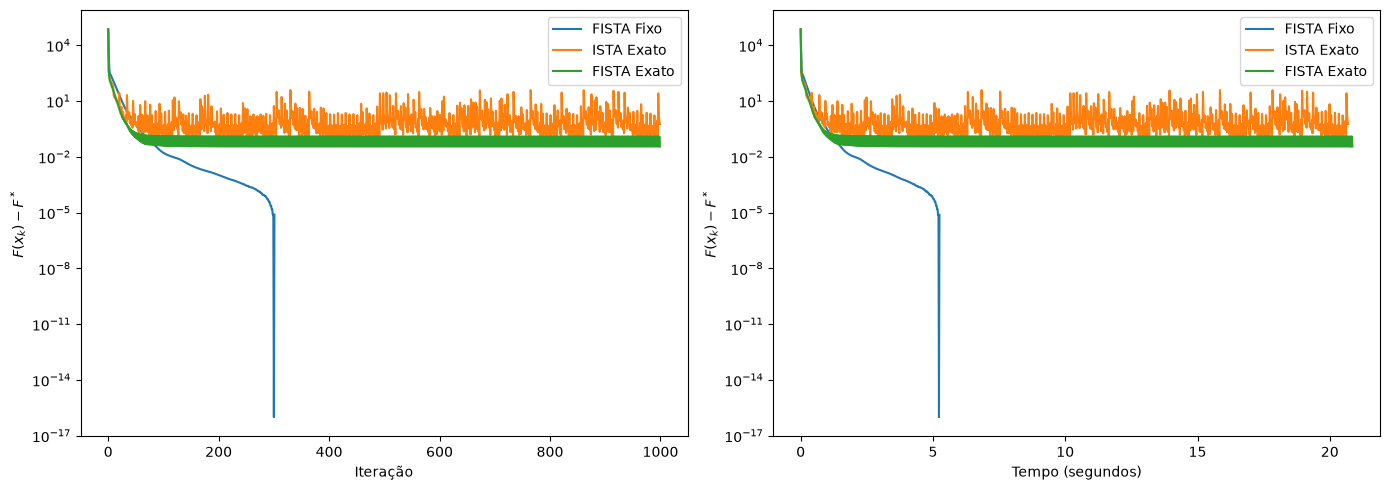

In [12]:
epsilon = 1e-16

names = list( results.keys() )

plt.figure( figsize = ( 14, 5 ) )

plt.subplot( 1, 2, 1 )
for name in names:
    vals = results[ name ][ "function_values" ]
    diff_vals = [ F - F_star + epsilon for F in vals ]
    plt.semilogy( diff_vals, label = name )

plt.xlabel( "Iteração" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()

plt.subplot( 1, 2, 2 )
for name in names:
    vals = np.array( results[ name ][ "function_values" ] )
    diff_vals = vals - F_star + epsilon
    
    total_time = results[ name ][ "avg_time" ]
    times = np.linspace( 0, total_time, len( vals ) )
    
    plt.semilogy( times, diff_vals, label = name )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "$F(x_k) - F^*$" )
plt.legend()

plt.tight_layout()
plt.show()

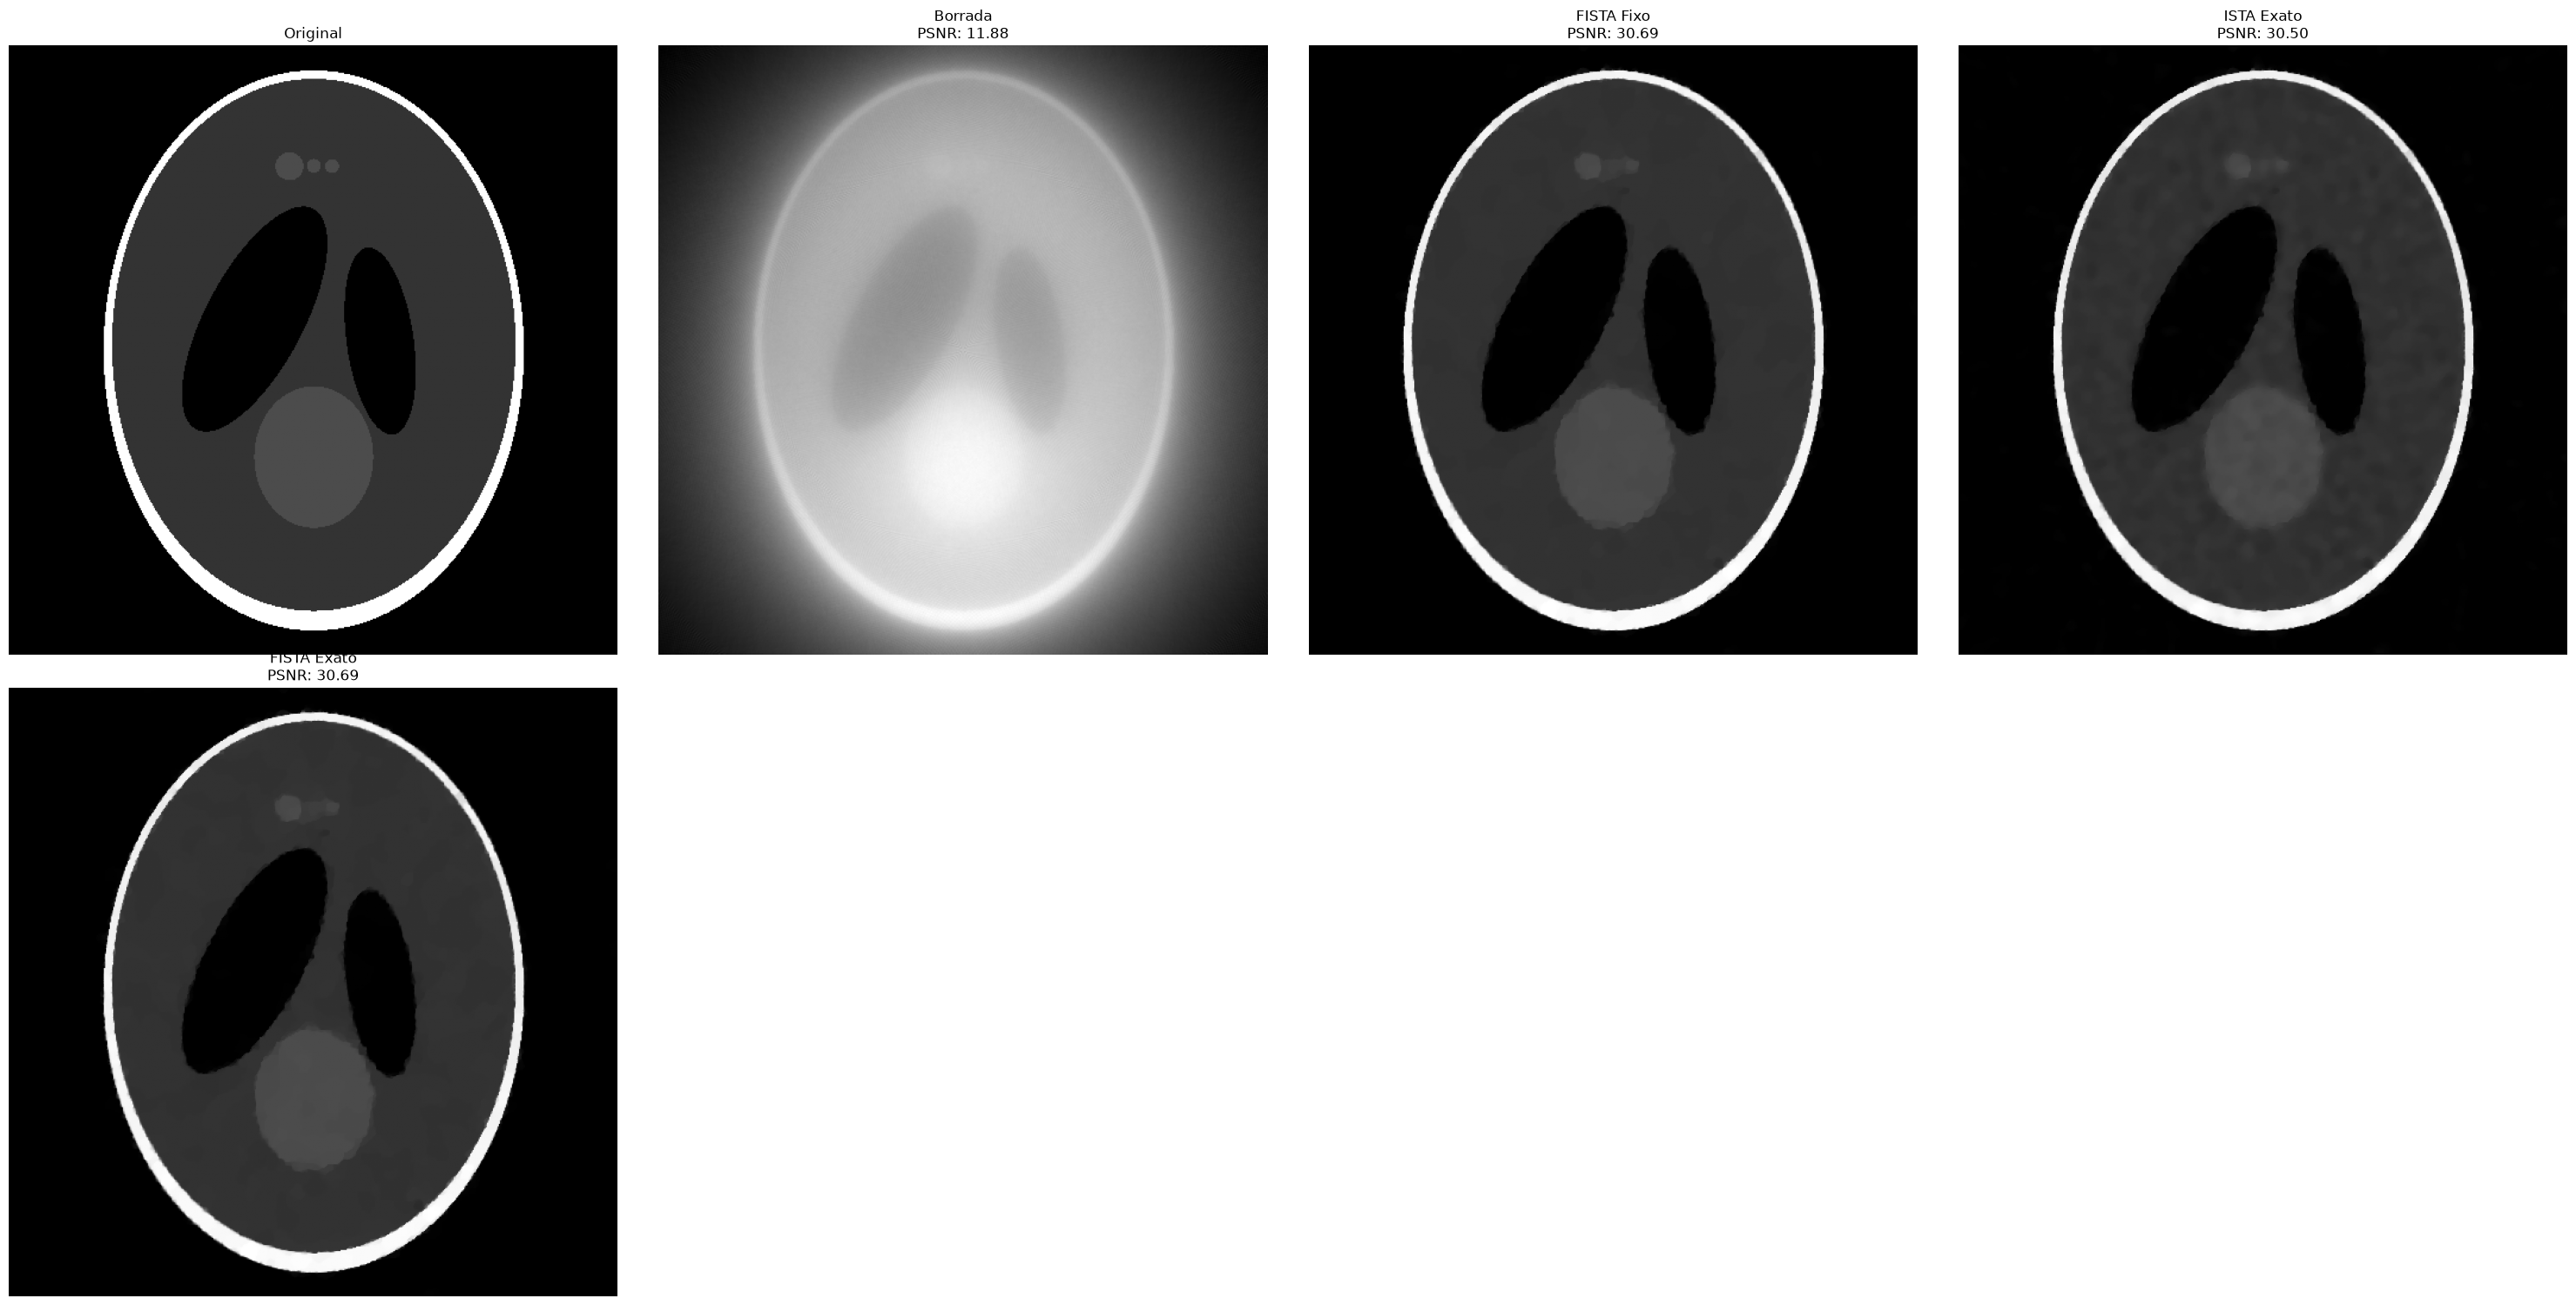

In [13]:
plt.figure( figsize = ( 30, 15 ) )

names = [ "FISTA Fixo", "ISTA Exato", "FISTA Exato" ]

plt.subplot( 2, 4, 1 )
plt.imshow( img.to( 'cpu' ).numpy(), cmap = 'gray' )
plt.title( "Original" )
plt.axis( "off" )

p_b = get_metrics( img.to( 'cpu' ).numpy(), b.to( 'cpu' ).numpy() )
plt.subplot( 2, 4, 2 )
plt.imshow( radon_transpose( b ).to( 'cpu' ).numpy(), cmap = 'gray' )
plt.title( f"Borrada\nPSNR: {p_b:.2f}" )
plt.axis( "off" )

for i, name in enumerate( names, start = 3 ):
    res_img = results[ name ][ "iters" ][ -1 ].to( 'cpu' )
    p = get_metrics( img.to( 'cpu' ).numpy(), res_img.to( 'cpu' ).numpy() )
    
    plt.subplot( 2, 4, i )
    plt.imshow( res_img, cmap = 'gray' )
    plt.title( f"{name}\nPSNR: {p:.2f}" )
    plt.axis( "off" )

plt.tight_layout()
plt.show()

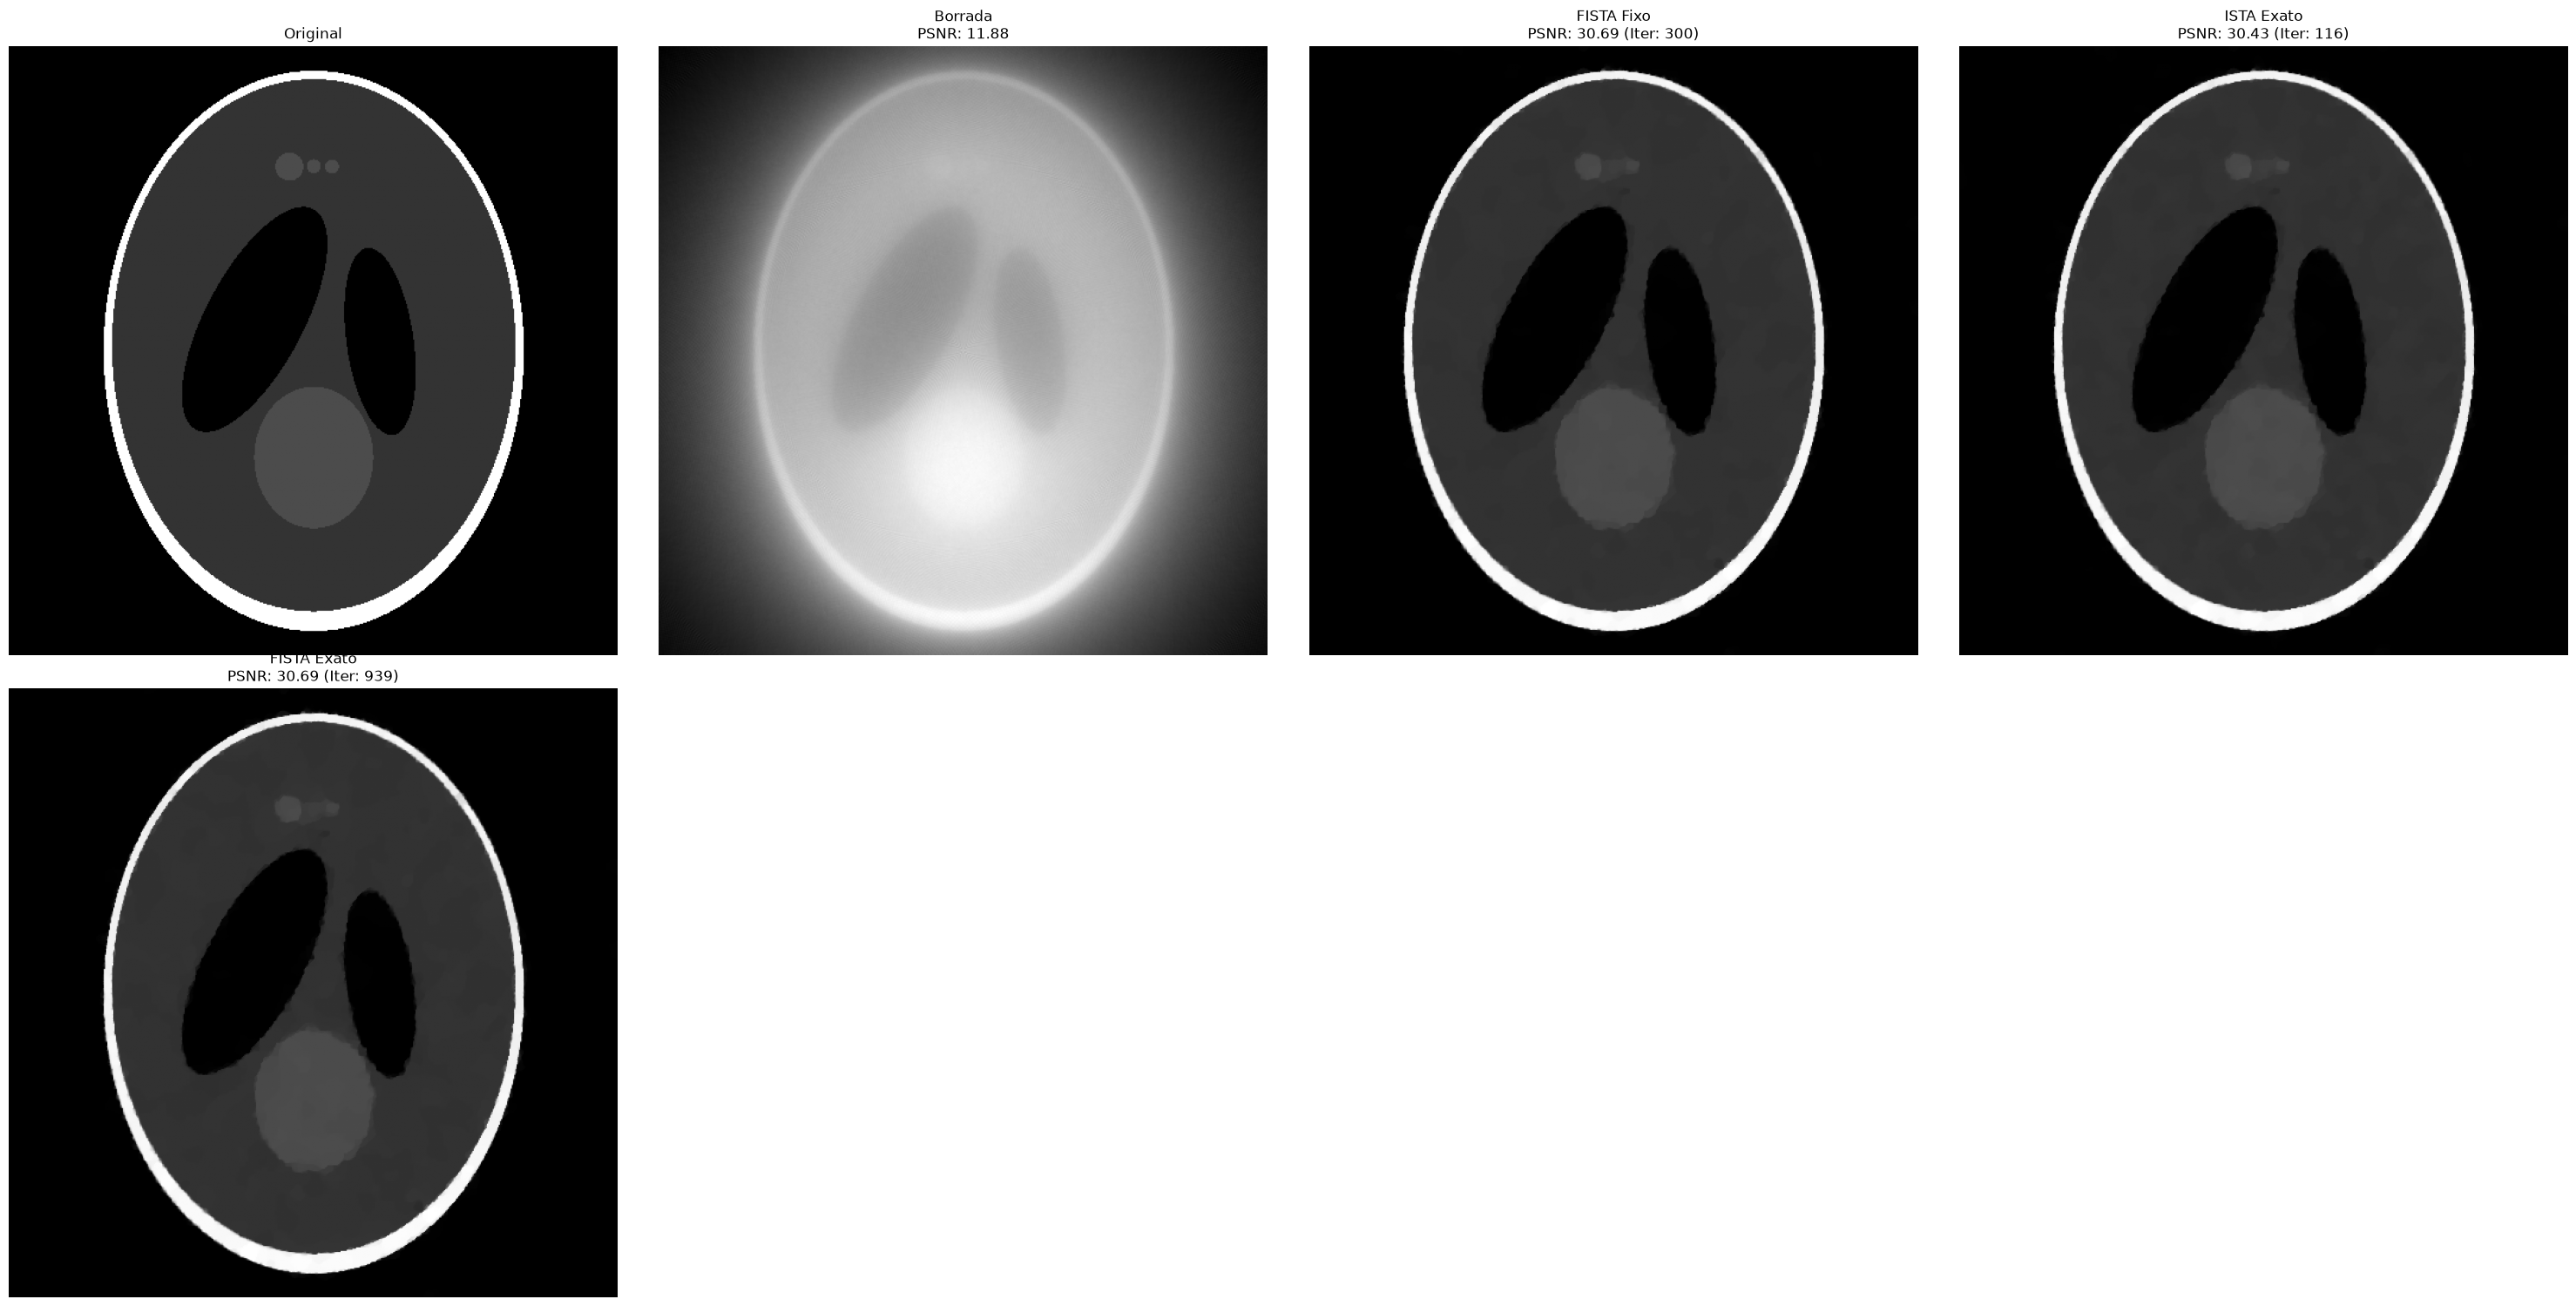

In [14]:
## vendo as melhores iterações de cada método e nao a ultima

plt.figure( figsize = ( 30, 15 ) )

plt.subplot( 2, 4, 1 )
plt.imshow( img.cpu().numpy(), cmap = 'gray' )
plt.title( "Original" )
plt.axis( "off" )

p_b = get_metrics( img.cpu().numpy(), b.cpu().numpy() )
plt.subplot( 2, 4, 2 )
plt.imshow( radon_transpose( b ).cpu().numpy(), cmap = 'gray' )
plt.title( f"Borrada\nPSNR: {p_b:.2f}" )
plt.axis( "off" )

for i, name in enumerate( names, start = 3 ):
    # 1. Descobre a iteração que gerou o menor valor da função objetivo
    idx_min = np.argmin( results[ name ][ "function_values" ] )
    
    # 2. Puxa a imagem exatamente dessa iteração ótima
    res_img = results[ name ][ "iters" ][ idx_min ].detach().cpu().numpy()
    
    p = get_metrics( img.cpu().numpy(), res_img )
    
    plt.subplot( 2, 4, i )
    plt.imshow( res_img, cmap = 'gray' )
    
    plt.title( f"{name}\nPSNR: {p:.2f} (Iter: {idx_min})" )
    plt.axis( "off" )

plt.tight_layout()
plt.show()

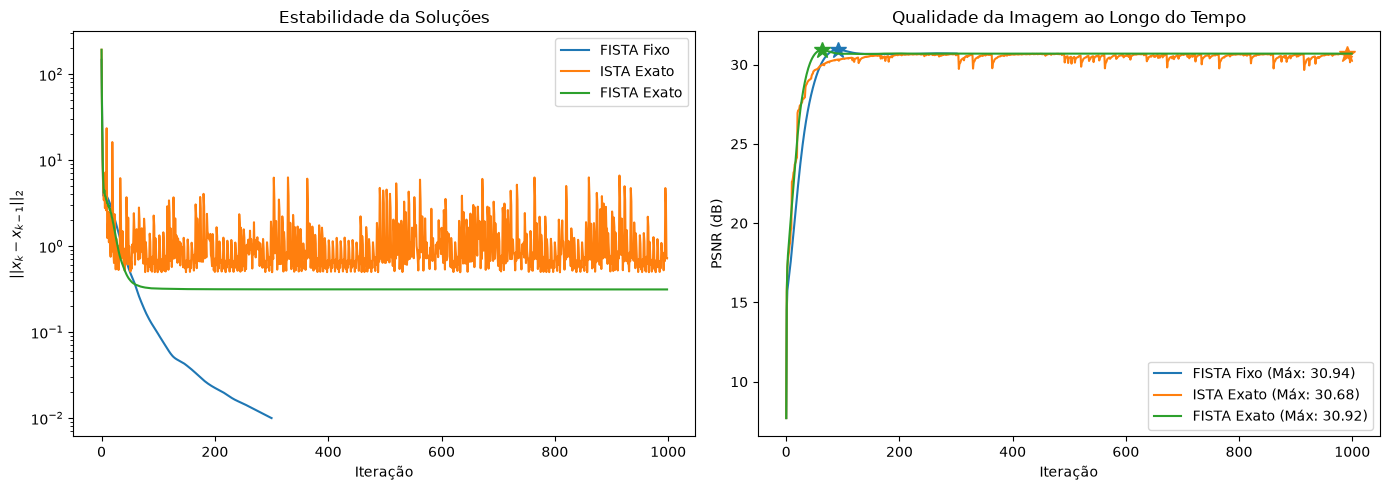

In [15]:
plt.figure( figsize = ( 14, 5 ) )

# 1. Distância entre iterações ||xk - xk-1||
plt.subplot( 1, 2, 1 )
for name in names:
    iters_list = results[ name ][ "iters" ]
    diffs = [ torch.linalg.norm( iters_list[i] - iters_list[i-1] ).item() for i in range( 1, len( iters_list ) ) ]
    
    plt.semilogy( diffs, label = name )

plt.xlabel( "Iteração" )
plt.ylabel( "$||x_k - x_{k-1}||_2$" )
plt.title( "Estabilidade da Soluções" )
plt.legend()

# 2. PSNR vs Iterações
plt.subplot( 1, 2, 2 )
img_np = img.cpu().numpy()

for name in names:
    iters_list = results[ name ][ "iters" ]
    
    psnr_vals = [ get_metrics( img_np, x.detach().cpu().numpy() ) for x in iters_list ] 
    iter_steps = np.arange( 0, len( iters_list ) )
    
    max_psnr = np.max( psnr_vals )
    idx_max = np.argmax( psnr_vals )
    
    line = plt.plot( iter_steps, psnr_vals, label = f"{name} (Máx: {max_psnr:.2f})" )[0]
    
    plt.plot( iter_steps[idx_max], max_psnr, marker = '*', markersize = 12, color = line.get_color() )

plt.xlabel( "Iteração" )
plt.ylabel( "PSNR (dB)" )
plt.title( "Qualidade da Imagem ao Longo do Tempo" )
plt.legend()

plt.tight_layout()
plt.show()

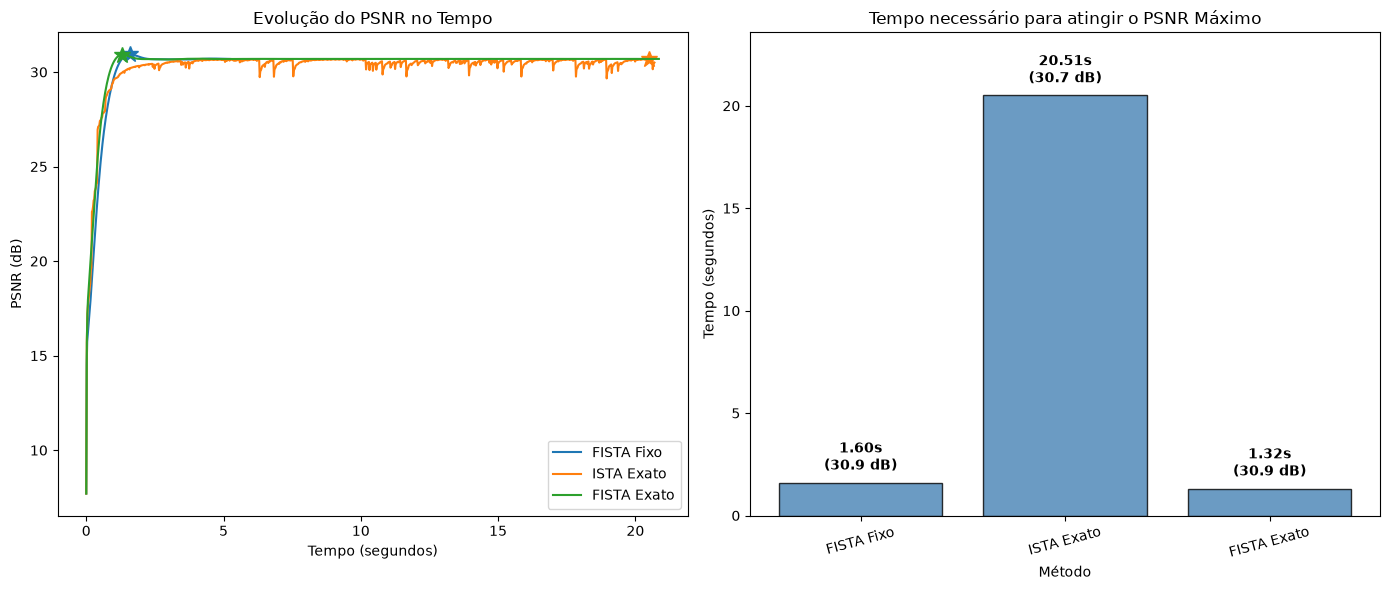

In [16]:
plt.figure( figsize = ( 14, 6 ) )

times_to_max = []
max_psnrs = []
valid_names = []

plt.subplot( 1, 2, 1 )
img_np = img.cpu().numpy()

for name in names:
    iters_list = results[ name ][ "iters" ]
    total_time = results[ name ][ "avg_time" ]
    
    psnr_vals = [ get_metrics( img_np, x.detach().cpu().numpy() ) for x in iters_list ] 
    
    times = np.linspace( 0, total_time, len( iters_list ) )
    
    max_psnr = np.max( psnr_vals )
    idx_max = np.argmax( psnr_vals )
    time_to_max = times[ idx_max ]
    
    times_to_max.append( time_to_max )
    max_psnrs.append( max_psnr )
    valid_names.append( name )
    
    line = plt.plot( times, psnr_vals, label = f"{name}" )[0]
    
    plt.plot( time_to_max, max_psnr, marker = '*', markersize = 12, color = line.get_color() )

plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "PSNR (dB)" )
plt.title( "Evolução do PSNR no Tempo" )
plt.legend()

plt.subplot( 1, 2, 2 )

bars = plt.bar( valid_names, times_to_max, color = 'steelblue', edgecolor = 'black', alpha = 0.8 )

for bar, psnr_val, t_max in zip( bars, max_psnrs, times_to_max ):
    yval = bar.get_height()
    plt.text( bar.get_x() + bar.get_width()/2, yval + ( 0.02 * max(times_to_max) ), 
              f"{t_max:.2f}s\n({psnr_val:.1f} dB)", 
              ha = 'center', va = 'bottom', fontsize = 10, fontweight = 'bold' )

plt.xlabel( "Método" )
plt.ylabel( "Tempo (segundos)" )
plt.title( "Tempo necessário para atingir o PSNR Máximo" )
plt.xticks( rotation = 15 )

plt.ylim( 0, max( times_to_max ) * 1.15 )

plt.tight_layout()
plt.show()